#  Tracking Pengeluaran Pribadi - Hematin

> **Dataset:** `final_finance_dataset.csv` — data transaksi nyata yang sudah dilabeli manual.

**Kolom dataset:** `tanggal_transaksi` · `nama_produk` · `kategori` · `total_rupiah`

**Kategori:** Makanan/Minuman · Tagihan/Utilitas · Hiburan · Kesehatan · Lain-lain

---

###  Latar Belakang & Tujuan

Pengelolaan keuangan pribadi seringkali dilakukan secara intuitif tanpa analisis berbasis data. Proyek ini bertujuan menganalisis **pola pengeluaran nyata selama ±10 tahun (2015–2024)** dari catatan transaksi harian yang telah dilabeli secara manual ke dalam 11 kategori.

**Pertanyaan utama yang ingin dijawab:**
1. Kategori apa yang paling menguras pengeluaran?
2. Bagaimana tren pengeluaran dari tahun ke tahun? Apakah meningkat?
3. Bulan apa yang secara konsisten pengeluarannya paling tinggi?
4. Kategori mana yang frekuensi transaksinya paling tinggi vs rata-rata per transaksinya?
5. Apakah ada transaksi anomali (outlier) yang signifikan?
6. Bagaimana komposisi pengeluaran berubah dari tahun ke tahun?
7. Hari apa dalam seminggu pengeluaran paling besar?

---




---
## 1. Setup & Import

Tahap awal dilakukan setup dan import library yang digunakan untuk proses analisis data, visualisasi, dan perhitungan statistik.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
})

KATEGORI_LIST = [
    'Lain-lain', 'Investasi','Belanja', 'Transportasi', 'Tagihan/Utilitas', 'Makanan/Minuman', 'Kesehatan', 'Hiburan', 'Pendidikan', 'Keuangan'
]
KATEGORI_COLOR = {
    'Lain-lain'         : '#757575',
    'Investasi'         : '#2E7D32',
    'Belanja'           : '#8E24AA',
    'Transportasi'      : '#00897B',
    'Tagihan/Utilitas'  : '#1565C0',
    'Makanan/Minuman'   : '#F57C00',
    'Kesehatan'         : '#D32F2F',
    'Hiburan'           : '#E91E63',
    'Pendidikan'        : '#6D4C41',
    'Keuangan'          : '#3949AB',
}

print(' Setup selesai')


 Setup selesai


Library yang digunakan meliputi:
- `pandas` dan `numpy` untuk manipulasi data,
- `matplotlib` dan `seaborn` untuk visualisasi,
- `scipy.stats` untuk analisis statistik,
- serta `warnings` untuk menyembunyikan warning yang tidak diperlukan.

Selain itu dilakukan konfigurasi:
- style visualisasi,
- ukuran figure,
- warna kategori,
- dan parameter tampilan grafik

agar hasil visualisasi lebih konsisten dan mudah dibaca selama proses Exploratory Data Analysis (EDA).

---
## 2. Load Dataset

Dataset yang digunakan merupakan dataset hasil proses wrangling sebelumnya yang berisi data transaksi pengeluaran pribadi.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df_raw = pd.read_csv(
   '/content/drive/MyDrive/Capstone_Project_DS/final_finance_dataset.csv'
)


print(f'Shape awal  : {df_raw.shape}')
print(f'Kolom       : {df_raw.columns.tolist()}')
df_raw.head(11)


Shape awal  : (9183, 4)
Kolom       : ['tanggal_transaksi', 'nama_produk', 'kategori', 'total_pengeluaran']


,tanggal_transaksi,nama_produk,kategori,total_pengeluaran
0,2023-04-25,movie tickets,Hiburan,3888.0
1,2023-12-31,books,Pendidikan,13239.0
2,2023-11-10,gym membership,Kesehatan,59543.0
3,2022-02-24,electricity bill,Tagihan/Utilitas,23760.0
4,2023-08-28,restaurant dinner,Makanan/Minuman,898.0
5,2024-07-17,atm withdrawal,Keuangan,9567.0
6,2024-04-20,gym membership,Kesehatan,7038.0
7,2024-12-16,books,Pendidikan,8119.0
8,2022-10-10,coffee,Makanan/Minuman,19947.0
9,2021-05-05,internet bill,Tagihan/Utilitas,2407.0


Tahap ini bertujuan untuk:
- memuat dataset ke dalam DataFrame,
- melihat struktur data awal,
- mengecek jumlah baris dan kolom,
- serta memastikan seluruh kolom berhasil dibaca dengan benar.

Dataset memiliki 4 kolom utama yaitu:
- `tanggal_transaksi`
- `nama_produk`
- `kategori`
- `total_pengeluaran`


---
## 3. Validasi Dataset Hasil Wrangling




Pada tahap ini dataset yang digunakan EDA merupakan hasil proses wrangling dan cleaning sebelumnya.


In [9]:
#  Validasi & pembersihan minor dataset hasil wrangling
df = df_raw.copy()

# 1. Parse tanggal
df['tanggal_transaksi'] = pd.to_datetime(
    df['tanggal_transaksi'],
    errors='coerce'
)

# 2. Hapus missing value penting
before = len(df)

df = df.dropna(
    subset=['nama_produk', 'tanggal_transaksi']
).reset_index(drop=True)

print(f'Baris null dihapus : {before - len(df)}')

# 3. Rapikan whitespace
df['nama_produk'] = (
    df['nama_produk']
    .astype(str)
    .str.strip()
)

df['kategori'] = (
    df['kategori']
    .astype(str)
    .str.strip()
)

# 4. Sort berdasarkan tanggal
df = (
    df.sort_values('tanggal_transaksi')
      .reset_index(drop=True)
)

# 5. Feature waktu
df['tahun'] = df['tanggal_transaksi'].dt.year
df['bulan'] = df['tanggal_transaksi'].dt.month
df['bulan_nama'] = df['tanggal_transaksi'].dt.strftime('%Y-%m')
df['hari_minggu'] = df['tanggal_transaksi'].dt.day_name()

# 6. Validasi dataset
print(f'\nDataset bersih : {df.shape[0]:,} baris, {df.shape[1]} kolom')
print(
    f'Rentang tanggal: '
    f'{df["tanggal_transaksi"].min().date()} '
    f'→ '
    f'{df["tanggal_transaksi"].max().date()}'
)
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')

# 7. Validasi kategori vs kategori referensi
kategori_dataset = sorted(df['kategori'].unique())
kategori_ref = sorted(KATEGORI_LIST)

print(f'Jumlah kategori dataset : {df["kategori"].nunique()}')
print(f'Kategori dataset        : {kategori_dataset}')
print(f'Kategori referensi      : {kategori_ref}')

kategori_tidak_sinkron = (
    set(df['kategori'].unique())
    - set(KATEGORI_LIST)
)

print(
    f'Kategori belum sinkron  : '
    f'{sorted(kategori_tidak_sinkron)}'
)

# Preview
df.head()

Baris null dihapus : 0

Dataset bersih : 9,183 baris, 8 kolom
Rentang tanggal: 2015-01-01 → 2024-12-31
Missing values : 0
Duplikat       : 0
Jumlah kategori dataset : 10
Kategori dataset        : ['Belanja', 'Hiburan', 'Investasi', 'Kesehatan', 'Keuangan', 'Lain-lain', 'Makanan/Minuman', 'Pendidikan', 'Tagihan/Utilitas', 'Transportasi']
Kategori referensi      : ['Belanja', 'Hiburan', 'Investasi', 'Kesehatan', 'Keuangan', 'Lain-lain', 'Makanan/Minuman', 'Pendidikan', 'Tagihan/Utilitas', 'Transportasi']
Kategori belum sinkron  : []


,tanggal_transaksi,nama_produk,kategori,total_pengeluaran,tahun,bulan,bulan_nama,hari_minggu
0,2015-01-01,share auto - hospital to brc station,Transportasi,1900.0,2015,1,2015-01,Thursday
1,2015-01-01,tea,Makanan/Minuman,1900.0,2015,1,2015-01,Thursday
2,2015-01-01,share jeep - place t top to base,Transportasi,3800.0,2015,1,2015-01,Thursday
3,2015-01-01,share jeep - place t to brc,Transportasi,11400.0,2015,1,2015-01,Thursday
4,2015-01-01,monument,Lain-lain,7600.0,2015,1,2015-01,Thursday


Tahap ini dilakukan untuk memastikan dataset siap digunakan pada proses Exploratory Data Analysis (EDA) serta memvalidasi konsistensi data hasil wrangling sebelumnya.

Proses yang dilakukan meliputi:
- parsing kolom `tanggal_transaksi` ke format datetime,
- penghapusan missing value pada data penting,
- pembersihan whitespace pada data teks,
- pengurutan data berdasarkan tanggal transaksi,
- pembuatan fitur waktu seperti tahun, bulan, dan hari,
- serta validasi kesesuaian kategori dataset dengan kategori referensi.

Hasil preprocessing menunjukkan:
- dataset akhir memiliki **9.183 baris dan 8 kolom**,
- tidak terdapat missing value maupun duplicate data,
- rentang transaksi berada pada periode **2015–2024**,
- serta seluruh kategori transaksi telah berhasil sinkron dengan daftar kategori referensi.

Selain itu, proses preprocessing menghasilkan fitur waktu tambahan seperti:
- `tahun`
- `bulan`
- `bulan_nama`
- `hari_minggu`

Feature tersebut digunakan untuk mendukung analisis temporal pada tahap EDA berikutnya.


---
## 4. Statistik Deskriptif

In [11]:
print('=' * 55)
print('STATISTIK DESKRIPTIF — total_rupiah')
print('=' * 55)
desc = df['total_pengeluaran'].describe()
print(desc.apply(lambda x: f'Rp {x:,.0f}' if x > 1000 else round(x, 2)))
print(f'Skewness : {df["total_pengeluaran"].skew():.2f}')
print(f'Kurtosis : {df["total_pengeluaran"].kurt():.2f}')


STATISTIK DESKRIPTIF — total_rupiah
count        Rp 9,183
mean        Rp 45,967
std        Rp 273,007
min              51.0
25%          Rp 3,448
50%          Rp 6,840
75%         Rp 18,512
max      Rp 9,500,000
Name: total_pengeluaran, dtype: object
Skewness : 19.03
Kurtosis : 486.73


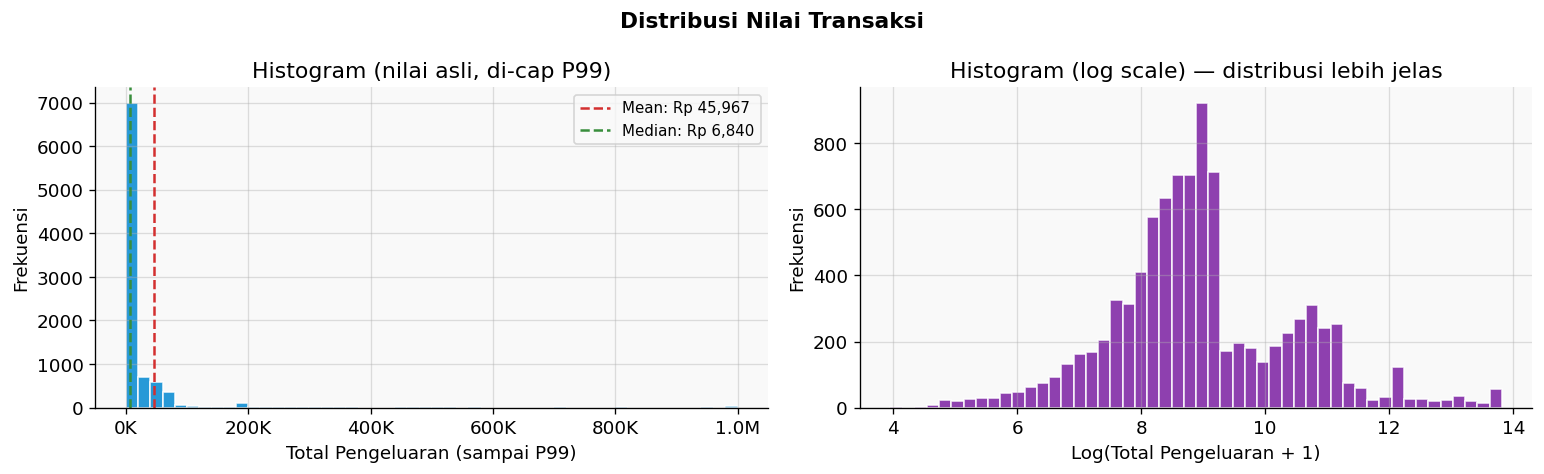

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Nilai Transaksi', fontweight='bold', fontsize=13)

# Histogram nilai asli (cap P99)
p99 = df['total_pengeluaran'].quantile(0.99)
data_vis = df[df['total_pengeluaran'] <= p99]['total_pengeluaran']

axes[0].hist(
    data_vis,
    bins=50,
    color='#0288D1',
    edgecolor='white',
    alpha=0.85
)

axes[0].axvline(
    df['total_pengeluaran'].mean(),
    color='#D32F2F',
    linestyle='--',
    linewidth=1.5,
    label=f'Mean: Rp {df["total_pengeluaran"].mean():,.0f}'
)

axes[0].axvline(
    df['total_pengeluaran'].median(),
    color='#388E3C',
    linestyle='--',
    linewidth=1.5,
    label=f'Median: Rp {df["total_pengeluaran"].median():,.0f}'
)

axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _:
        f'{x/1e6:.1f}M'
        if x >= 1e6
        else f'{x/1e3:.0f}K'
    )
)

axes[0].set_xlabel('Total Pengeluaran (sampai P99)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Histogram (nilai asli, di-cap P99)')
axes[0].legend(fontsize=9)

# Histogram log-scale
axes[1].hist(
    np.log1p(data_vis),
    bins=50,
    color='#7B1FA2',
    edgecolor='white',
    alpha=0.85
)

axes[1].set_xlabel('Log(Total Pengeluaran + 1)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Histogram (log scale) — distribusi lebih jelas')

plt.tight_layout()
plt.show()

**Penjelasan:**

Distribusi nilai transaksi menunjukkan pola yang **sangat right-skewed (miring ke kanan)**, di mana sebagian besar transaksi memiliki nominal kecil hingga menengah, sementara hanya sebagian kecil transaksi bernilai sangat besar.

Histogram nilai asli yang dibatasi hingga persentil ke-99 (P99) membantu memperjelas distribusi utama tanpa terlalu dipengaruhi oleh transaksi ekstrem. Terlihat bahwa sebagian besar transaksi terkonsentrasi pada nominal rendah.

Nilai **mean (~Rp45.967)** berada jauh di atas **median (~Rp6.840)**, yang mengindikasikan bahwa terdapat transaksi besar yang menarik rata-rata ke arah lebih tinggi.

Pada histogram log scale, distribusi terlihat lebih menyebar dan relatif lebih simetris. Transformasi log membantu mengurangi efek right-skewness sehingga pola distribusi data lebih mudah dianalisis dan divisualisasikan.

Temuan ini menunjukkan bahwa data transaksi memiliki rentang nilai yang lebar dan dipengaruhi oleh transaksi bernilai tinggi, sehingga penggunaan log transform maupun metode robust seperti median dan IQR menjadi relevan pada tahap analisis lanjutan.


---
## 5. Pertanyaan Bisnis (SMART)




|  | Pertanyaan | Metrik |
|---|---|---|
| 1 | Kategori apa yang paling menguras pengeluaran?| Sum `total_rupiah` per kategori |
| 2 | Bagaimana tren pengeluaran dari tahun ke tahun? Apakah meningkat? | Sum per tahun & growth rate |
| 3 | Bulan apa yang secara konsisten pengeluarannya paling tinggi? | Rata-rata sum per bulan lintas tahun |
| 4 | Kategori mana yang frekuensi transaksinya paling tinggi vs rata-rata per transaksinya? | Count & mean per kategori |
| 5 | Apakah ada transaksi anomali (outlier) yang signifikan? | Z-score & IQR analysis |
| 6 | Bagaimana komposisi pengeluaran berubah dari tahun ke tahun? | Stacked proportion per tahun |
| 7 | Hari apa dalam seminggu pengeluaran paling besar? | Mean & sum per hari |



---
### 5.1 Kategori apa yang paling menguras pengeluaran?





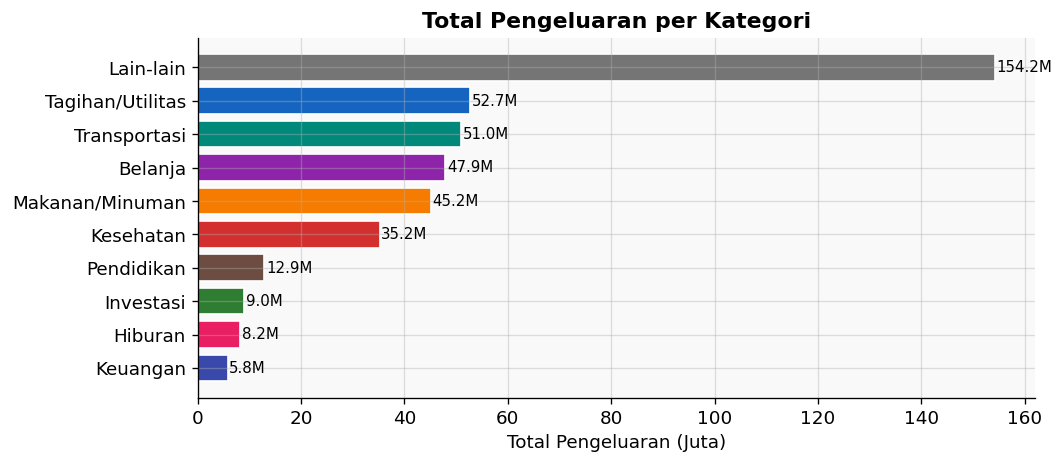

In [13]:
# BQ1: Kategori pengeluaran terbesar
kat_total = (
    df.groupby('kategori')['total_pengeluaran']
      .sum()
      .sort_values(ascending=True)
)

kat_count = (
    df.groupby('kategori')['total_pengeluaran']
      .count()
      .reindex(kat_total.index)
)

fig, ax = plt.subplots(figsize=(9, 4))

colors_total = [
    KATEGORI_COLOR.get(k, '#757575')
    for k in kat_total.index
]

bars = ax.barh(
    kat_total.index,
    kat_total.values / 1e6,
    color=colors_total,
    edgecolor='white'
)

ax.set_xlabel('Total Pengeluaran (Juta)')
ax.set_title(
    'Total Pengeluaran per Kategori',
    fontweight='bold'
)

for bar, val in zip(bars, kat_total.values):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val/1e6:.1f}M',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

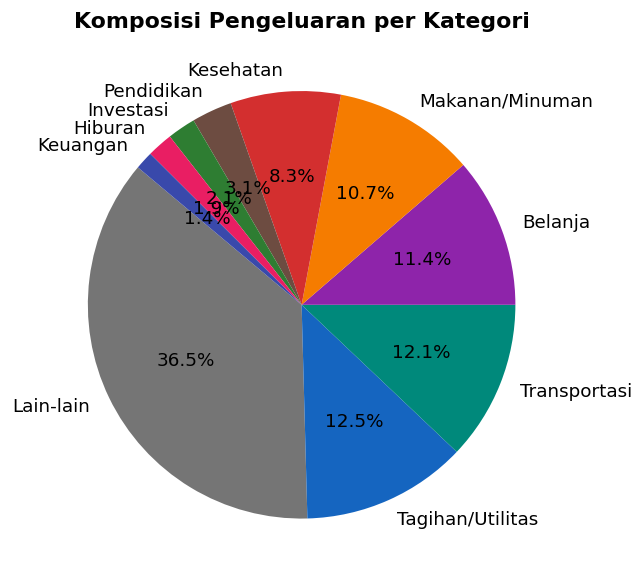

In [14]:
# Treemap komposisi pengeluaran
try:
    import squarify
    HAS_SQUARIFY = True
except ImportError:
    HAS_SQUARIFY = False

kat_for_treemap = (
    df.groupby('kategori')['total_pengeluaran']
      .sum()
      .sort_values(ascending=False)
)

colors_tm = [
    KATEGORI_COLOR.get(k, '#757575')
    for k in kat_for_treemap.index
]

labels_tm = [
    f'{k}\nRp {v/1e6:.1f}M\n({v/kat_for_treemap.sum()*100:.1f}%)'
    for k, v in kat_for_treemap.items()
]

fig, ax = plt.subplots(figsize=(13, 5))

if HAS_SQUARIFY:
    squarify.plot(
        sizes=kat_for_treemap.values,
        label=labels_tm,
        color=colors_tm,
        alpha=0.85,
        ax=ax,
        text_kwargs={'fontsize': 9.5}
    )

    ax.set_title(
        'Treemap Komposisi Pengeluaran per Kategori',
        fontweight='bold',
        fontsize=13
    )
    ax.axis('off')

else:
    ax.pie(
        kat_for_treemap.values,
        labels=kat_for_treemap.index,
        colors=colors_tm,
        autopct='%1.1f%%',
        startangle=140
    )

    ax.set_title(
        'Komposisi Pengeluaran per Kategori',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Penjelasan Pertanyaan No 1

Berdasarkan hasil analisis total pengeluaran per kategori, kategori **Lain-lain** memiliki total pengeluaran tertinggi yaitu sekitar **Rp154,2 juta** atau **36,5%** dari total pengeluaran keseluruhan. Di sisi lain, kategori seperti **Tagihan/Utilitas**, **Transportasi**, **Belanja**, dan **Makanan/Minuman** juga memberikan kontribusi pengeluaran yang cukup signifikan.

Hal ini menunjukkan bahwa pengeluaran tidak hanya terfokus pada satu jenis kebutuhan, melainkan tersebar pada beberapa kategori dengan proporsi yang bervariasi.

Kategori dengan total pengeluaran tinggi berikutnya meliputi:

- **Tagihan/Utilitas** sekitar **Rp52,7 juta** (12,5%)
- **Transportasi** sekitar **Rp51,0 juta** (12,1%)
- **Belanja** sekitar **Rp47,9 juta** (11,4%)
- **Makanan/Minuman** sekitar **Rp45,2 juta** (10,7%)
- **Kesehatan** sekitar **Rp35,2 juta** (8,3%)

Sementara itu, kategori dengan total pengeluaran lebih rendah yaitu:

- **Pendidikan** sekitar **Rp12,9 juta** (3,1%)
- **Investasi** sekitar **Rp9,0 juta** (2,1%)
- **Hiburan** sekitar **Rp8,2 juta** (2,0%)
- **Keuangan** sekitar **Rp5,8 juta** (1,4%)

Visualisasi bar chart dan pie chart menunjukkan bahwa pengeluaran tidak hanya terpusat pada kebutuhan rutin seperti makanan dan tagihan, tetapi juga cukup besar pada kategori **Transportasi** dan **Belanja**. Hal ini menggambarkan bahwa pola pengeluaran mencakup berbagai kebutuhan sehari-hari dengan distribusi yang relatif beragam.

Di sisi lain, besarnya proporsi pada kategori **Lain-lain** perlu diperhatikan karena kategori ini bersifat umum dan dapat berisi berbagai jenis transaksi yang belum terkelompok secara rinci. Kondisi ini mengindikasikan bahwa proses kategorisasi masih dapat disempurnakan agar distribusi pengeluaran menjadi lebih spesifik dan interpretasi analisis menjadi semakin akurat.

Secara keseluruhan, hasil analisis menunjukkan bahwa pengeluaran memiliki pola yang cukup beragam, meskipun kategori **Lain-lain** tetap menjadi penyumbang pengeluaran terbesar dibanding kategori lainnya.


---
### 5.2 Bagaimana tren pengeluaran dari tahun ke tahun? Apakah meningkat?





Pengeluaran per Tahun:
            total  count      mean  growth_%
tahun                                       
2015   33408916.0    337   99136.0       NaN
2016   63855998.0    313  204013.0      91.1
2017   95458217.0    873  109345.0      49.5
2018   77067279.0    564  136644.0     -19.3
2021   36578964.0   1727   21181.0     -52.5
2022   40601864.0   1785   22746.0      11.0
2023   33261275.0   1755   18952.0     -18.1
2024   41880629.0   1829   22898.0      25.9


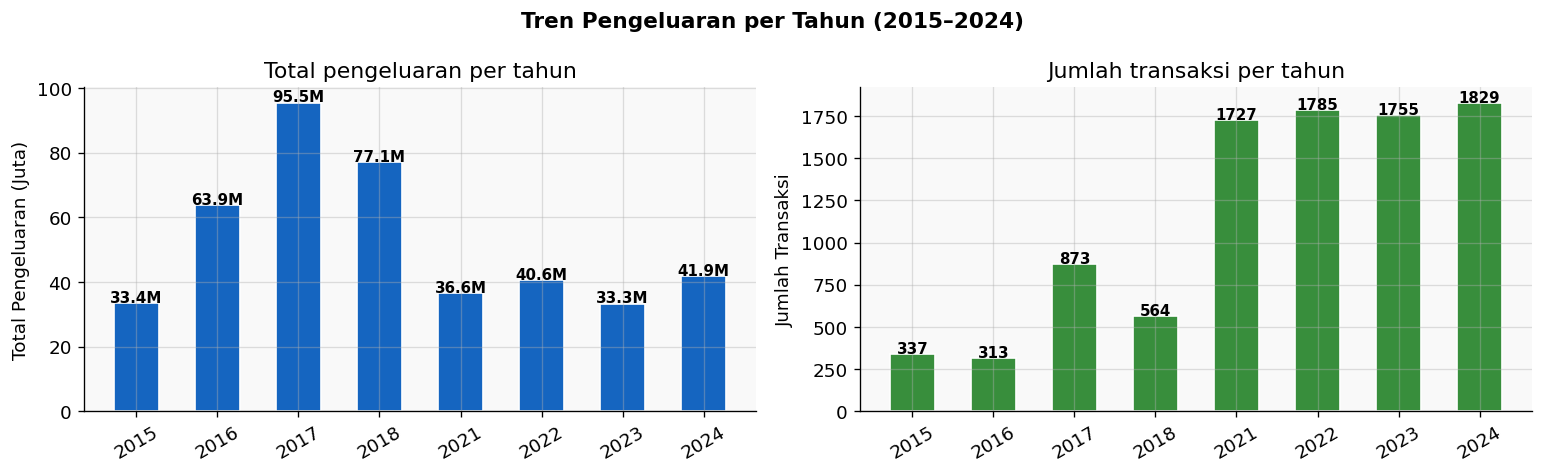

In [16]:
# Pengeluaran per tahun
yearly = df.groupby('tahun').agg(
    total=('total_pengeluaran', 'sum'),
    count=('total_pengeluaran', 'count'),
    mean=('total_pengeluaran', 'mean')
).round(0)

yearly['growth_%'] = (
    yearly['total']
    .pct_change()
    .mul(100)
    .round(1)
)

print('Pengeluaran per Tahun:')
print(yearly.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Tren Pengeluaran per Tahun (2015–2024)',
    fontweight='bold',
    fontsize=13
)

years = yearly.index.astype(str)

# Total pengeluaran
bars0 = axes[0].bar(
    years,
    yearly['total'] / 1e6,
    color='#1565C0',
    width=0.55,
    edgecolor='white'
)

axes[0].set_ylabel('Total Pengeluaran (Juta)')
axes[0].set_title('Total pengeluaran per tahun')

for bar, val in zip(bars0, yearly['total']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val/1e6:.1f}M',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

axes[0].tick_params(axis='x', rotation=30)

# Jumlah transaksi
bars1 = axes[1].bar(
    years,
    yearly['count'],
    color='#388E3C',
    width=0.55,
    edgecolor='white'
)

axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_title('Jumlah transaksi per tahun')

for bar, val in zip(bars1, yearly['count']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(int(val)),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

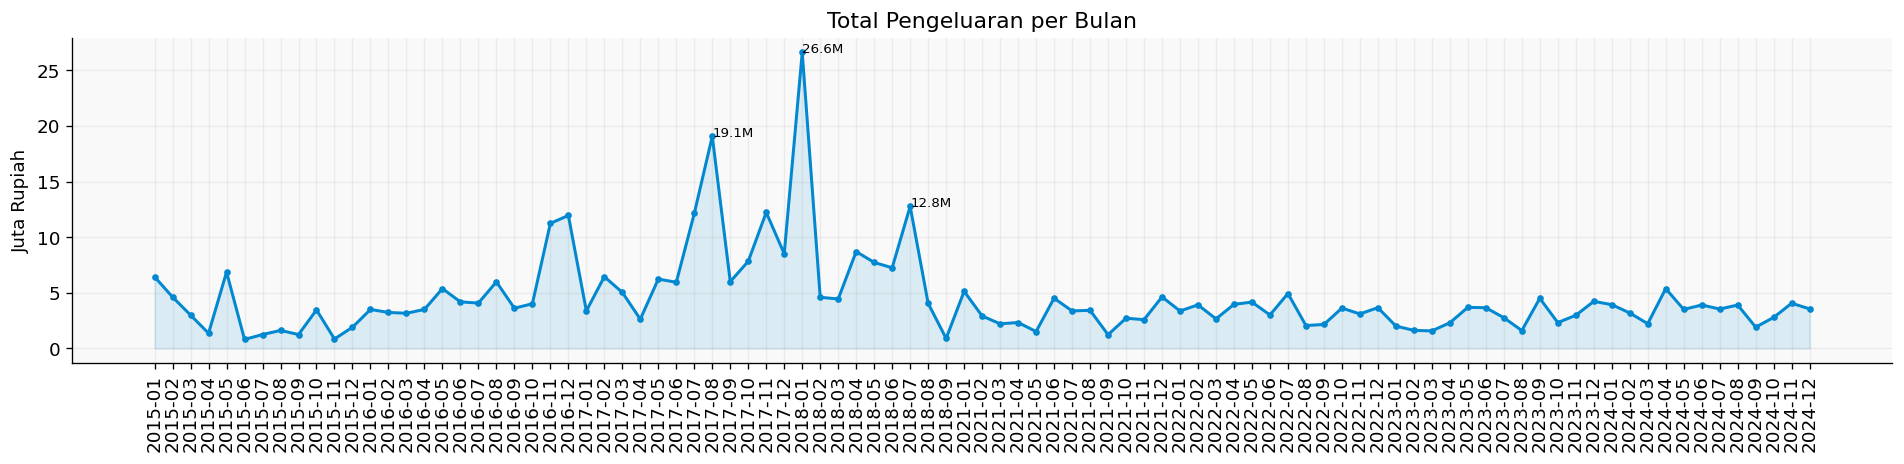

In [18]:
# Tren bulanan (line chart)
monthly = (
    df.groupby(['bulan_nama', 'bulan'])['total_pengeluaran']
      .sum()
      .reset_index()
      .sort_values(['bulan_nama'])
)

fig, ax = plt.subplots(figsize=(16, 4))

x = range(len(monthly))

ax.plot(
    x,
    monthly['total_pengeluaran'] / 1e6,
    color='#0288D1',
    linewidth=1.8,
    marker='o',
    markersize=3
)

ax.fill_between(
    x,
    monthly['total_pengeluaran'] / 1e6,
    alpha=0.12,
    color='#0288D1'
)

# Annotate top-3 spike
top3 = monthly.nlargest(3, 'total_pengeluaran')

for _, row in top3.iterrows():
    idx = monthly[
        monthly['bulan_nama'] == row['bulan_nama']
    ].index[0]

    ax.text(
        idx,
        row['total_pengeluaran'] / 1e6,
        f'{row["total_pengeluaran"]/1e6:.1f}M',
        fontsize=8
    )

ax.set_title('Total Pengeluaran per Bulan')
ax.set_ylabel('Juta Rupiah')

ax.set_xticks(x)
ax.set_xticklabels(monthly['bulan_nama'], rotation=90)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Penjelasan Pertanyaan No 2

Berdasarkan hasil analisis, total pengeluaran menunjukkan pola yang **berfluktuasi dari tahun ke tahun** dan tidak mengalami peningkatan secara konsisten pada seluruh periode pengamatan.

Pada awal periode (**2015–2018**), total pengeluaran masih berada pada tingkat yang relatif lebih rendah dengan jumlah transaksi di bawah **1.000 transaksi per tahun**. Total pengeluaran meningkat dari sekitar **Rp33,4 juta pada tahun 2015** menjadi **Rp63,9 juta pada tahun 2016**, lalu mencapai puncak pada **tahun 2017** sebesar sekitar **Rp95,5 juta** dengan **873 transaksi**. Namun pada **2018**, total pengeluaran mengalami penurunan menjadi sekitar **Rp77,1 juta**.

Pada periode berikutnya (**2021–2024**), jumlah transaksi meningkat cukup signifikan dan berada di atas **1.700 transaksi per tahun**. Meskipun demikian, total pengeluaran tidak selalu meningkat secara linear. Tahun **2021** mencatat total pengeluaran sekitar **Rp36,6 juta**, kemudian meningkat menjadi sekitar **Rp40,6 juta pada tahun 2022**. Setelah itu terjadi penurunan pada **2023** menjadi sekitar **Rp33,3 juta**, sebelum kembali meningkat pada **2024** menjadi sekitar **Rp41,9 juta**.

Selain perubahan nominal pengeluaran, jumlah transaksi tahunan juga menunjukkan kecenderungan meningkat, yaitu:
- **2015 : 337 transaksi**
- **2017 : 873 transaksi**
- **2021 : 1.727 transaksi**
- **2024 : 1.829 transaksi**

Hal ini menunjukkan bahwa perubahan total pengeluaran tidak hanya dipengaruhi oleh besar kecilnya nominal transaksi, tetapi juga dipengaruhi oleh intensitas aktivitas transaksi yang terjadi pada setiap tahun.

Visualisasi tren bulanan memperlihatkan adanya beberapa **lonjakan pengeluaran (spike)** pada bulan-bulan tertentu. Sebagian besar bulan memiliki nilai pengeluaran yang relatif stabil, namun terdapat beberapa periode dengan pengeluaran yang jauh lebih tinggi dibanding bulan lainnya. Kondisi ini mengindikasikan adanya transaksi bernilai besar atau periode pengeluaran yang lebih intensif pada waktu tertentu.

Secara keseluruhan, hasil analisis menunjukkan bahwa tren pengeluaran **tidak meningkat secara konsisten dari tahun ke tahun**, melainkan mengalami **fluktuasi dengan aktivitas transaksi yang cenderung meningkat**, terutama pada periode akhir pengamatan.


---
### 5.3 Bulan yang Secara Konsisten Pengeluarannya Paling Tinggi





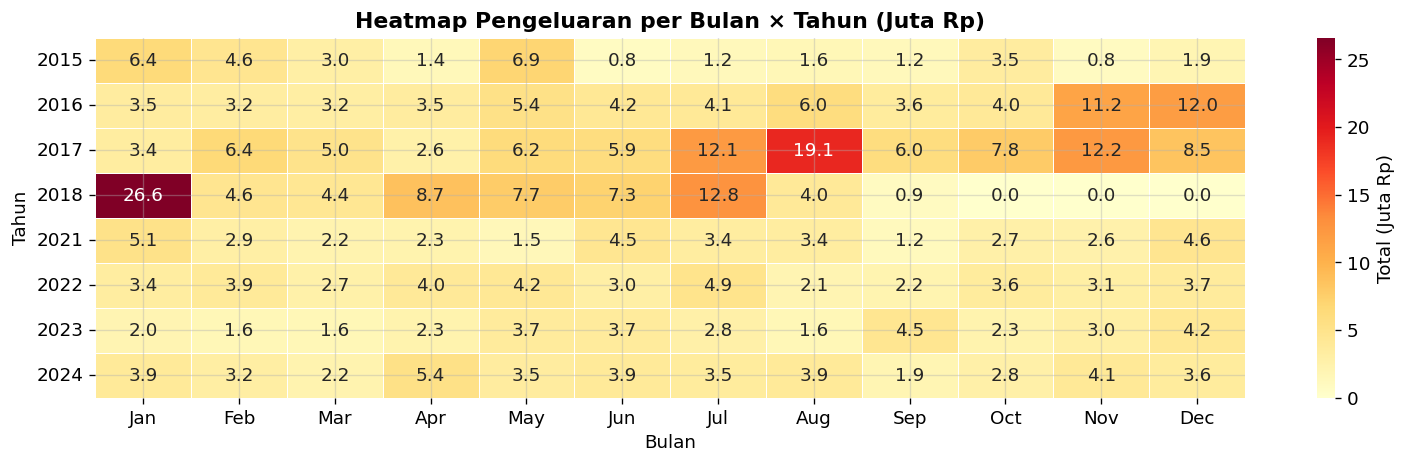

In [20]:
# Heatmap pengeluaran bulan × tahun
bulan_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
all_months = list(bulan_map.values())

pivot = df.pivot_table(values='total_pengeluaran', index='tahun', columns='bulan',
                       aggfunc='sum', fill_value=0)
pivot.columns = [bulan_map[c] for c in pivot.columns]
for m in all_months:
    if m not in pivot.columns:
        pivot[m] = 0
pivot = pivot[all_months]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Total (Juta Rp)'}, ax=ax)
ax.set_title('Heatmap Pengeluaran per Bulan × Tahun (Juta Rp)', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Tahun')
plt.tight_layout()
plt.show()

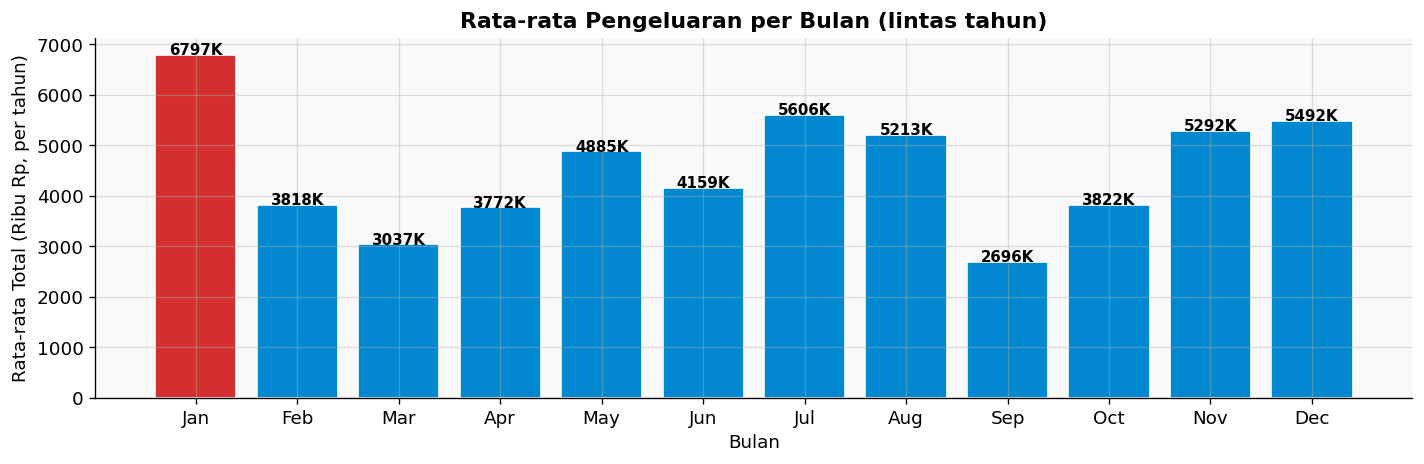

Bulan dengan rata-rata tertinggi : Jan (Rp 6,796,812)
Catatan: Menggunakan rata-rata per tahun agar tidak bias oleh spike satu bulan spesifik.


In [22]:
# Rata-rata pengeluaran per bulan lintas tahun
monthly_total = df.groupby('bulan')['total_pengeluaran'].sum()
years_per_month = df.groupby(['bulan','tahun']).size().groupby('bulan').count()
monthly_avg = (monthly_total / years_per_month).round(0)
monthly_avg.index = [bulan_map[i] for i in monthly_avg.index]

fig, ax = plt.subplots(figsize=(12, 4))
colors_m = ['#D32F2F' if v == monthly_avg.max() else '#0288D1' for v in monthly_avg.values]
bars = ax.bar(monthly_avg.index, monthly_avg.values / 1e3, color=colors_m, edgecolor='white')
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val/1e3:.0f}K', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Rata-rata Total (Ribu Rp, per tahun)')
ax.set_title('Rata-rata Pengeluaran per Bulan (lintas tahun)', fontweight='bold')
ax.set_xlabel('Bulan')
plt.tight_layout()
plt.show()

top_bulan = monthly_avg.idxmax()
print(f'Bulan dengan rata-rata tertinggi : {top_bulan} (Rp {monthly_avg.max():,.0f})')
print('Catatan: Menggunakan rata-rata per tahun agar tidak bias oleh spike satu bulan spesifik.')


### Penjelasan Pertanyaan No 3

Berdasarkan hasil analisis rata-rata pengeluaran bulanan lintas tahun, bulan dengan **pengeluaran rata-rata tertinggi** adalah **Januari** dengan rata-rata pengeluaran sekitar **Rp6.796.812** per tahun. Nilai ini menunjukkan bahwa pada awal tahun cenderung terjadi aktivitas pengeluaran yang lebih tinggi dibanding bulan lainnya.

Selain Januari, beberapa bulan lain yang juga memiliki rata-rata pengeluaran cukup tinggi yaitu:

- **Juli** sekitar **Rp5.606.406**
- **Desember** sekitar **Rp5.492.000**
- **November** sekitar **Rp5.292.000**
- **Agustus** sekitar **Rp5.213.000**
- **Mei** sekitar **Rp4.885.000**

Sementara itu, bulan dengan rata-rata pengeluaran yang relatif lebih rendah adalah:

- **September** sekitar **Rp2.696.000**
- **Maret** sekitar **Rp3.037.000**
- **Februari** sekitar **Rp3.818.000**
- **Oktober** sekitar **Rp3.822.000**
- **April** sekitar **Rp3.772.000**

Visualisasi heatmap menunjukkan bahwa lonjakan pengeluaran tidak terjadi secara merata setiap tahun. Beberapa bulan memperlihatkan **spike pengeluaran** yang cukup besar pada periode tertentu, misalnya **Januari 2018** yang mencapai sekitar **Rp26.600.000**, serta lonjakan lain pada **Juli–Agustus 2017** dan **November–Desember 2016**. Kondisi ini menunjukkan bahwa pengeluaran tinggi pada bulan tertentu dapat dipengaruhi oleh transaksi bernilai besar atau kebutuhan khusus pada periode tersebut.

Penggunaan **rata-rata lintas tahun** membantu mengurangi bias akibat transaksi ekstrem atau lonjakan pada satu tahun tertentu sehingga pola bulanan dapat terlihat lebih stabil dan konsisten. Dengan pendekatan ini, dapat disimpulkan bahwa **awal tahun (Januari) serta pertengahan hingga akhir tahun (Juli–Desember)** cenderung memiliki tingkat pengeluaran yang lebih tinggi dibanding bulan lainnya.


---
### 5.4 Frekuensi Transaksi Tertinggi vs Rata-rata per Transaksi





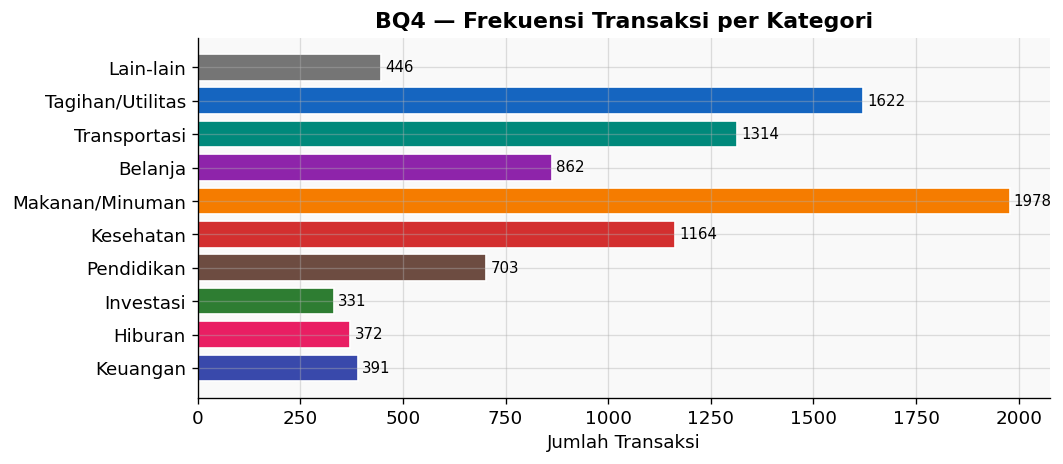

In [23]:
# BQ4: Frekuensi transaksi per kategori
fig, ax = plt.subplots(figsize=(9, 4))
colors_count = [KATEGORI_COLOR.get(k, '#757575') for k in kat_count.index]
bars2 = ax.barh(kat_count.index, kat_count.values, color=colors_count, edgecolor='white')
ax.set_xlabel('Jumlah Transaksi')
ax.set_title('BQ4 — Frekuensi Transaksi per Kategori', fontweight='bold')
for bar, val in zip(bars2, kat_count.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)
plt.tight_layout()
plt.show()


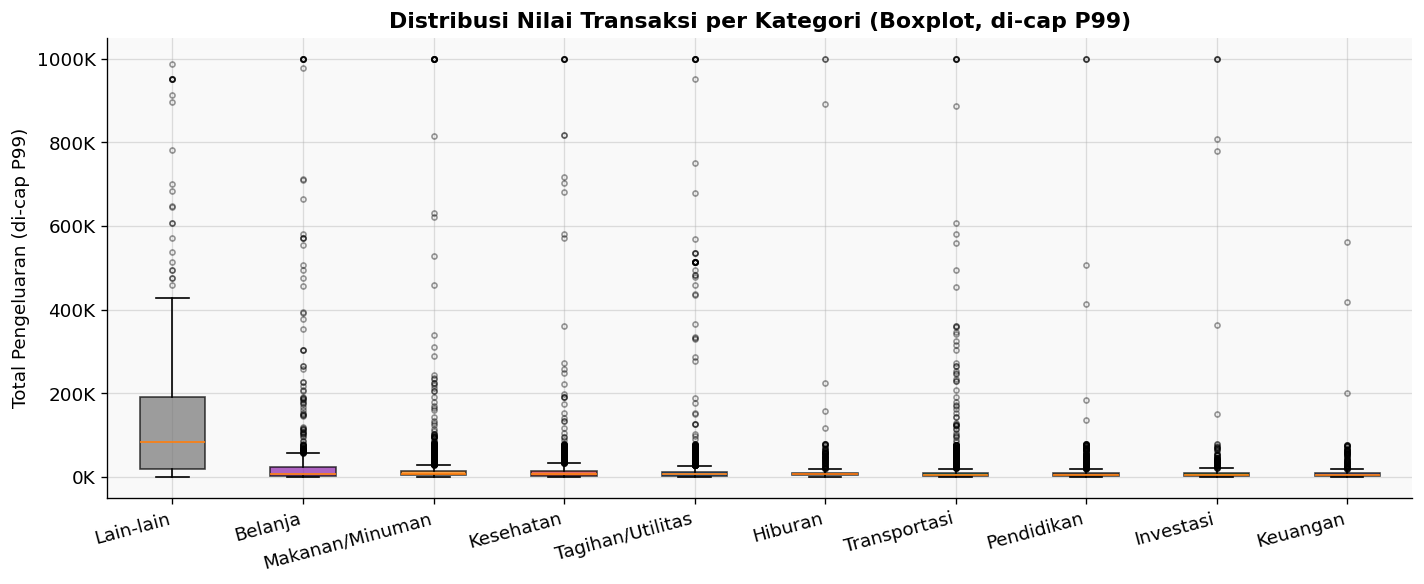

In [25]:
# Boxplot nilai transaksi per kategori
order = (
    df.groupby('kategori')['total_pengeluaran']
      .median()
      .sort_values(ascending=False)
      .index
)

fig, ax = plt.subplots(figsize=(12, 5))

# Cap outlier di P99 agar visualisasi lebih jelas
p99_global = df['total_pengeluaran'].quantile(0.99)
df_vis = df[df['total_pengeluaran'] <= p99_global]

bp = ax.boxplot(
    [
        df_vis[df_vis['kategori'] == k]['total_pengeluaran'].values
        for k in order
    ],
    labels=order,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(
        marker='o',
        markersize=3,
        alpha=0.4
    )
)

for patch, k in zip(bp['boxes'], order):
    patch.set_facecolor(
        KATEGORI_COLOR.get(k, '#757575')
    )
    patch.set_alpha(0.7)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K'
    )
)

ax.set_ylabel('Total Pengeluaran (di-cap P99)')
ax.set_title(
    'Distribusi Nilai Transaksi per Kategori (Boxplot, di-cap P99)',
    fontweight='bold'
)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Penjelasan Pertanyaan No 4

Berdasarkan hasil analisis frekuensi transaksi per kategori, kategori dengan **jumlah transaksi tertinggi** adalah **Makanan/Minuman** dengan total sekitar **1.978 transaksi**. Hal ini menunjukkan bahwa pengeluaran pada kategori tersebut terjadi paling sering dibanding kategori lainnya, sehingga dapat dikategorikan sebagai kebutuhan rutin atau pengeluaran dengan frekuensi tinggi.

Kategori dengan frekuensi transaksi tinggi berikutnya adalah:

- **Tagihan/Utilitas** sebanyak **1.622 transaksi**
- **Transportasi** sebanyak **1.314 transaksi**
- **Kesehatan** sebanyak **1.164 transaksi**
- **Belanja** sebanyak **862 transaksi**
- **Pendidikan** sebanyak **703 transaksi**

Sementara itu, kategori dengan jumlah transaksi relatif lebih rendah meliputi:

- **Lain-lain** sebanyak **446 transaksi**
- **Keuangan** sebanyak **391 transaksi**
- **Hiburan** sebanyak **372 transaksi**
- **Investasi** sebanyak **331 transaksi**

Visualisasi boxplot menunjukkan bahwa distribusi nilai transaksi pada setiap kategori cenderung **right-skewed**, yaitu sebagian besar transaksi berada pada nominal rendah hingga menengah, tetapi terdapat sejumlah transaksi bernilai tinggi yang muncul sebagai **outlier**. Untuk memperjelas pola utama distribusi, visualisasi dibatasi hingga **persentil ke-99 (P99)** sehingga transaksi ekstrem tidak mendominasi tampilan grafik.

Kategori **Lain-lain** memperlihatkan rentang transaksi yang cukup lebar dibanding beberapa kategori lain, ditunjukkan oleh ukuran box dan banyaknya titik outlier. Hal ini mengindikasikan bahwa kategori tersebut berisi transaksi dengan nominal yang sangat beragam dan kemungkinan mencakup berbagai jenis pengeluaran yang belum terklasifikasi secara spesifik.

Di sisi lain, kategori seperti **Makanan/Minuman** memiliki frekuensi transaksi yang sangat tinggi, namun median nilai transaksinya relatif lebih rendah dibanding kategori dengan transaksi yang lebih jarang tetapi bernilai besar. Temuan ini menunjukkan bahwa **tingginya frekuensi transaksi tidak selalu sejalan dengan besarnya rata-rata nilai transaksi**, karena beberapa kategori memiliki sedikit transaksi namun nominal per transaksi lebih tinggi.

Secara keseluruhan, hasil analisis memperlihatkan bahwa pola pengeluaran terdiri atas dua karakteristik utama, yaitu kategori dengan **frekuensi tinggi dan nominal relatif kecil** seperti Makanan/Minuman, serta kategori dengan **frekuensi lebih rendah tetapi variasi nominal lebih besar** seperti Lain-lain dan beberapa kategori lainnya.


---
### 5.5 Transaksi Anomali (Outlier) yang Signifikan




In [26]:
# BQ5: Deteksi outlier dengan Z-score dan IQR

# Z-score digunakan sebagai referensi awal
# Namun karena distribusi sangat right-skewed,
# metode IQR lebih representatif untuk mendeteksi outlier.

z_scores = np.abs(
    stats.zscore(df['total_pengeluaran'])
)

outlier_z = df[
    z_scores > 3
].copy()

Q1 = df['total_pengeluaran'].quantile(0.25)
Q3 = df['total_pengeluaran'].quantile(0.75)
IQR_val = Q3 - Q1

outlier_iqr = df[
    (
        df['total_pengeluaran']
        < Q1 - 1.5 * IQR_val
    )
    |
    (
        df['total_pengeluaran']
        > Q3 + 1.5 * IQR_val
    )
].copy()

print(f'Q1 (P25)         : Rp {Q1:,.0f}')
print(f'Q3 (P75)         : Rp {Q3:,.0f}')
print(f'IQR              : Rp {IQR_val:,.0f}')
print(
    f'Batas atas (IQR) : '
    f'Rp {Q3 + 1.5 * IQR_val:,.0f}'
)
print(
    f'Outlier (Z-score): '
    f'{len(outlier_z):,} transaksi'
)
print(
    f'Outlier (IQR)    : '
    f'{len(outlier_iqr):,} transaksi'
)

Q1 (P25)         : Rp 3,448
Q3 (P75)         : Rp 18,512
IQR              : Rp 15,064
Batas atas (IQR) : Rp 41,108
Outlier (Z-score): 108 transaksi
Outlier (IQR)    : 1,428 transaksi


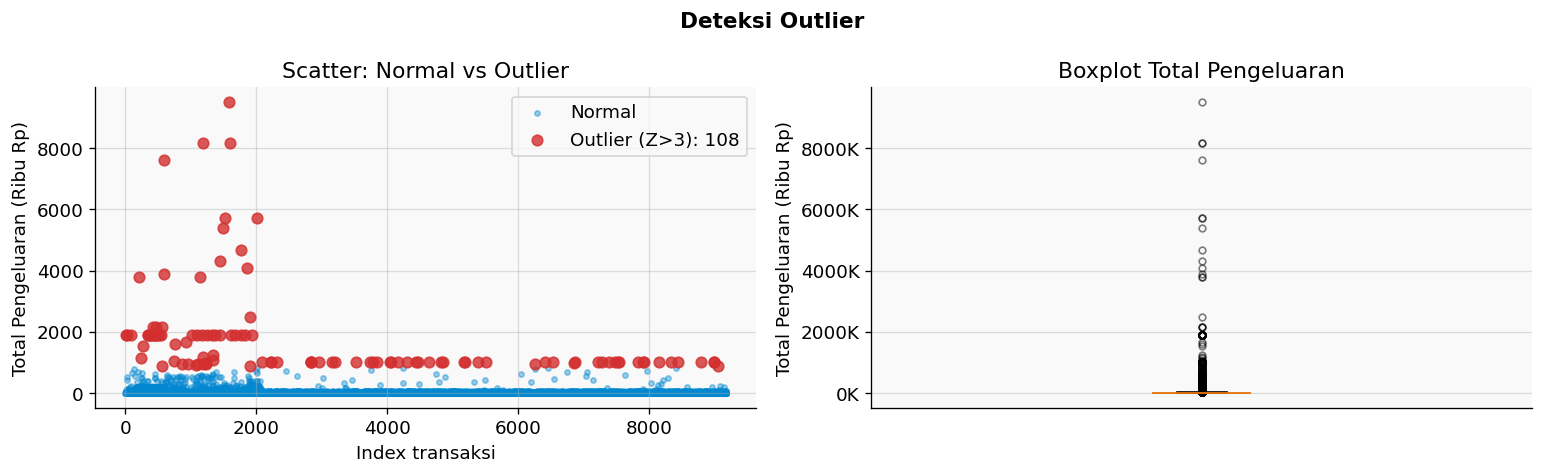

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Deteksi Outlier',
    fontweight='bold',
    fontsize=13
)

is_outlier_flag = z_scores > 3

# Scatter normal vs outlier
axes[0].scatter(
    df.index[~is_outlier_flag],
    df['total_pengeluaran'][~is_outlier_flag] / 1e3,
    alpha=0.4,
    s=10,
    color='#0288D1',
    label='Normal'
)

axes[0].scatter(
    df.index[is_outlier_flag],
    df['total_pengeluaran'][is_outlier_flag] / 1e3,
    alpha=0.8,
    s=40,
    color='#D32F2F',
    label=f'Outlier (Z>3): {is_outlier_flag.sum()}',
    zorder=5
)

axes[0].set_xlabel('Index transaksi')
axes[0].set_ylabel('Total Pengeluaran (Ribu Rp)')
axes[0].set_title('Scatter: Normal vs Outlier')
axes[0].legend()

# Boxplot total pengeluaran
axes[1].boxplot(
    df['total_pengeluaran'] / 1e3,
    vert=True,
    patch_artist=True,
    boxprops=dict(
        facecolor='#0288D1',
        alpha=0.6
    ),
    flierprops=dict(
        marker='o',
        color='#D32F2F',
        markersize=4,
        alpha=0.5
    )
)

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x:.0f}K'
    )
)

axes[1].set_ylabel('Total Pengeluaran (Ribu Rp)')
axes[1].set_title('Boxplot Total Pengeluaran')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

In [29]:
# Distribusi outlier per kategori
print('Distribusi outlier (Z>3) per kategori:')
print(outlier_z['kategori'].value_counts())
print()
print('Rata-rata nilai outlier per kategori:')
print(outlier_z.groupby('kategori')['total_pengeluaran'].agg(['count','mean','max']).round(0))


Distribusi outlier (Z>3) per kategori:
kategori
Lain-lain           46
Belanja             13
Tagihan/Utilitas    11
Makanan/Minuman     11
Transportasi        10
Kesehatan            8
Investasi            3
Pendidikan           3
Hiburan              3
Name: count, dtype: int64

Rata-rata nilai outlier per kategori:
                  count       mean        max
kategori                                     
Belanja              13  1671505.0  4085000.0
Hiburan               3   964072.0   999999.0
Investasi             3   999999.0   999999.0
Kesehatan             8  1436137.0  4313000.0
Lain-lain            46  2294923.0  8170000.0
Makanan/Minuman      11   999999.0   999999.0
Pendidikan            3   999999.0   999999.0
Tagihan/Utilitas     11  1401671.0  5396000.0
Transportasi         10  2574078.0  9500000.0


### Penjelasan Pertanyaan No 5

Berdasarkan hasil analisis menggunakan metode **Z-score** dan **Interquartile Range (IQR)**, ditemukan adanya transaksi anomali (*outlier*) pada dataset pengeluaran.

Hasil perhitungan menunjukkan bahwa:

- **Q1 (25%)** sebesar sekitar **Rp3.448**
- **Q3 (75%)** sebesar sekitar **Rp18.512**
- **IQR** sebesar sekitar **Rp15.064**
- **Batas atas outlier (IQR)** sebesar sekitar **Rp41.168**

Deteksi outlier menggunakan dua metode menghasilkan jumlah yang berbeda, yaitu:

- metode **Z-score** mendeteksi sekitar **108 transaksi outlier**
- metode **IQR** mendeteksi sekitar **1.428 transaksi outlier**

Perbedaan jumlah tersebut terjadi karena distribusi data pengeluaran bersifat **right-skewed** atau condong ke kanan, di mana sebagian besar transaksi bernilai kecil namun terdapat sejumlah transaksi bernilai jauh lebih besar. Pada kondisi seperti ini, metode **IQR cenderung lebih sensitif** dalam mengidentifikasi transaksi bernilai tinggi dibanding metode Z-score yang berbasis rata-rata dan standar deviasi.

Visualisasi **scatter plot** menunjukkan bahwa mayoritas transaksi terkonsentrasi pada nominal rendah hingga menengah, sementara sejumlah kecil transaksi berada jauh di atas distribusi utama dan teridentifikasi sebagai outlier. Temuan serupa juga terlihat pada **boxplot**, di mana banyak titik outlier muncul di atas whisker sehingga menandakan adanya transaksi dengan nominal yang jauh lebih tinggi dibanding pola umum data.

Distribusi outlier berdasarkan kategori memperlihatkan bahwa kategori **Lain-lain** memiliki jumlah outlier terbanyak yaitu sekitar **46 transaksi**, diikuti oleh:

- **Belanja** : **13 transaksi**
- **Tagihan/Utilitas** : **11 transaksi**
- **Makanan/Minuman** : **11 transaksi**
- **Transportasi** : **10 transaksi**
- **Kesehatan** : **8 transaksi**

Temuan ini menunjukkan bahwa transaksi ekstrem tidak hanya muncul pada satu kategori tertentu, tetapi tersebar pada beberapa jenis pengeluaran dengan intensitas yang berbeda.

Berdasarkan rata-rata nominal outlier, kategori **Transportasi** memiliki rata-rata outlier tertinggi yaitu sekitar **Rp257.408** dengan transaksi maksimum mencapai sekitar **Rp9.500.000**. Sementara itu, kategori **Lain-lain** memiliki jumlah outlier paling banyak dengan rata-rata nilai sekitar **Rp229.492** dan transaksi maksimum sekitar **Rp8.170.000**.

Secara keseluruhan, hasil analisis menunjukkan bahwa dataset memiliki distribusi yang **tidak normal** dan dipengaruhi oleh sejumlah transaksi bernilai tinggi. Oleh karena itu, keberadaan outlier perlu diperhatikan pada tahap analisis lanjutan maupun pemodelan agar tidak menyebabkan bias pada interpretasi maupun performa model.


---
### 5.6 Komposisi Pengeluaran Berubah dari Tahun ke Tahun


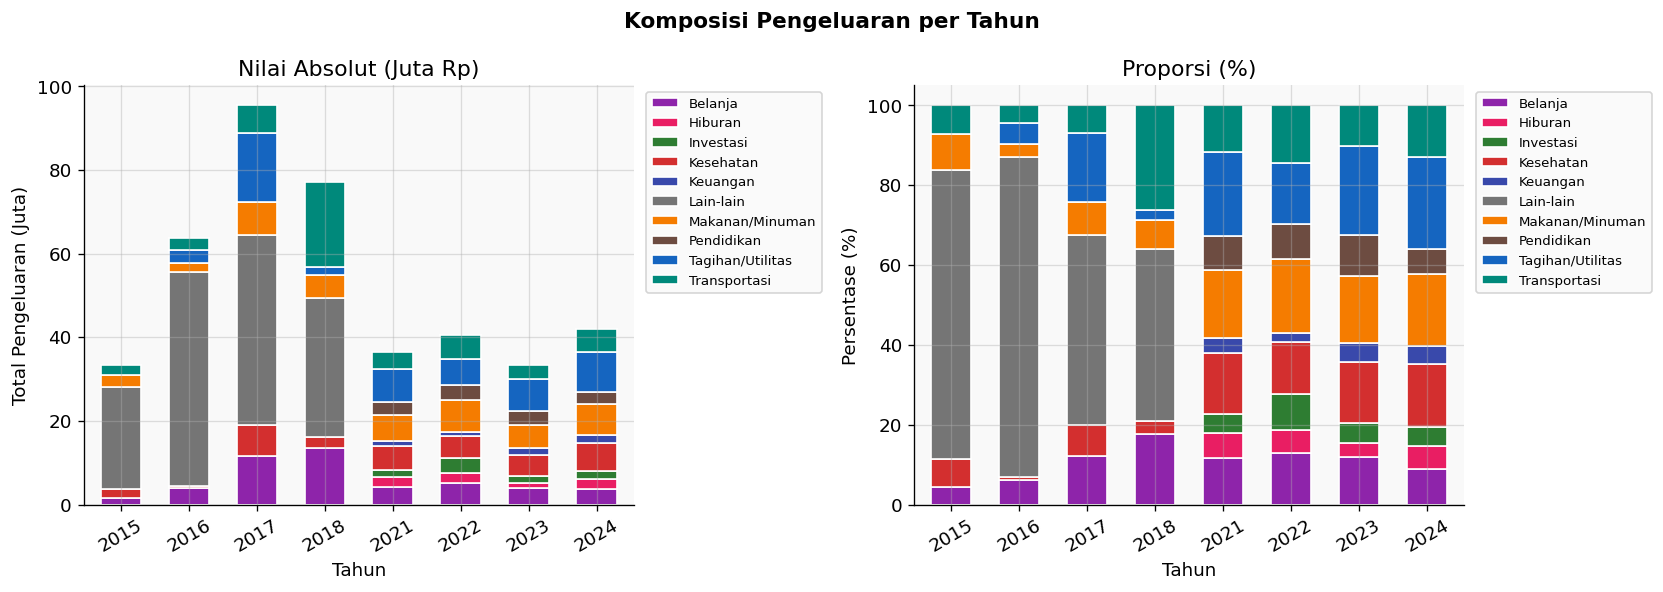

In [30]:
# BQ6: Komposisi pengeluaran per tahun

yr_kat = (
    df.groupby(['tahun', 'kategori'])['total_pengeluaran']
      .sum()
      .unstack(fill_value=0)
)

yr_kat_pct = (
    yr_kat.div(
        yr_kat.sum(axis=1),
        axis=0
    ) * 100
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

fig.suptitle(
    'Komposisi Pengeluaran per Tahun',
    fontweight='bold',
    fontsize=13
)

# Nilai absolut
yr_kat.div(1e6).plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=[
        KATEGORI_COLOR.get(k, '#757575')
        for k in yr_kat.columns
    ],
    edgecolor='white',
    width=0.6
)

axes[0].set_title('Nilai Absolut (Juta Rp)')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Total Pengeluaran (Juta)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)

# Proporsi (%)
yr_kat_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=[
        KATEGORI_COLOR.get(k, '#757575')
        for k in yr_kat_pct.columns
    ],
    edgecolor='white',
    width=0.6
)

axes[1].set_title('Proporsi (%)')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)

plt.tight_layout()
plt.show()

### Penjelasan Pertanyaan No 6

Berdasarkan hasil analisis komposisi pengeluaran per tahun, **komposisi pengeluaran terbukti berubah dari tahun ke tahun** baik dari sisi nilai absolut maupun proporsi masing-masing kategori.
Visualisasi stacked bar nilai absolut menunjukkan bahwa total pengeluaran mengalami fluktuasi dari tahun ke tahun. Pada periode awal (**2015–2018**), pengeluaran relatif lebih tinggi terutama pada **2016–2017**, sementara pada periode **2021–2024** total pengeluaran berada pada kisaran yang lebih stabil meskipun tetap mengalami kenaikan dan penurunan pada beberapa tahun.

Dari sisi nominal, kategori **Lain-lain** terlihat menjadi salah satu penyumbang terbesar pada hampir seluruh periode pengamatan. Selain itu, kategori seperti **Transportasi**, **Tagihan/Utilitas**, dan **Makanan/Minuman** juga memberikan kontribusi yang cukup besar terhadap total pengeluaran tahunan.

Visualisasi proporsi (%) menunjukkan bahwa komposisi pengeluaran tidak bersifat tetap setiap tahun. Pada beberapa tahun awal, kategori **Lain-lain** mendominasi sebagian besar pengeluaran, yang mengindikasikan adanya banyak transaksi yang masih berada pada kategori umum atau belum terklasifikasi secara lebih spesifik.

Pada periode **2021–2024**, distribusi pengeluaran terlihat lebih tersebar antar kategori. Kontribusi **Transportasi**, **Tagihan/Utilitas**, **Makanan/Minuman**, dan **Kesehatan** menjadi lebih terlihat sehingga komposisi pengeluaran tidak lagi terlalu terpusat pada satu kategori saja. Kondisi ini menunjukkan bahwa kebutuhan dan prioritas pengeluaran berubah seiring waktu.

Kategori seperti **Makanan/Minuman** dan **Tagihan/Utilitas** cenderung mempertahankan kontribusi yang cukup konsisten dari tahun ke tahun, mencerminkan karakteristiknya sebagai kebutuhan rutin. Sebaliknya, kategori seperti **Lain-lain** dan beberapa kategori lain menunjukkan variasi proporsi yang lebih besar, yang mengindikasikan adanya pengeluaran yang bersifat situasional atau tidak rutin.

Secara keseluruhan, hasil analisis menunjukkan bahwa **komposisi pengeluaran bersifat dinamis dan berubah dari tahun ke tahun**, baik karena perubahan nominal total maupun pergeseran prioritas pengeluaran pada masing-masing kategori.


---
### 5.7 Hari Pengeluaran Paling Besar


Pengeluaran per Hari dalam Seminggu:
             total  rata_rata  jumlah_transaksi
Senin   62790243.0    44218.0              1420
Selasa  69442814.0    51978.0              1336
Rabu    51138428.0    41917.0              1220
Kamis   77639461.0    57810.0              1343
Jumat   53359011.0    42997.0              1241
Sabtu   50768403.0    40197.0              1263
Minggu  56974782.0    41893.0              1360


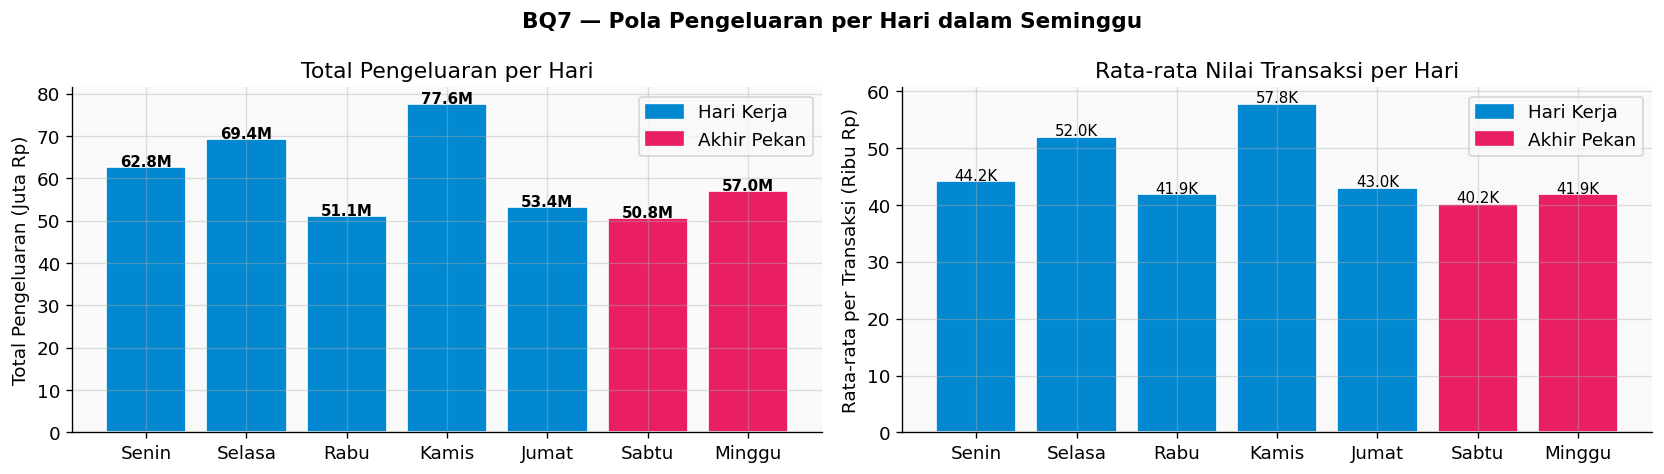

In [31]:
DAY_ORDER = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

DAY_ID = [
    'Senin','Selasa','Rabu',
    'Kamis','Jumat','Sabtu','Minggu'
]

# Statistik per hari
day_stats = (
    df.groupby('hari_minggu')['total_pengeluaran']
      .agg(['sum','mean','count'])
      .reindex(DAY_ORDER)
)

day_stats.index = DAY_ID
day_stats.columns = [
    'total',
    'rata_rata',
    'jumlah_transaksi'
]

print('Pengeluaran per Hari dalam Seminggu:')
print(day_stats.round(0).to_string())

# Visualisasi
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 4)
)

fig.suptitle(
    'BQ7 — Pola Pengeluaran per Hari dalam Seminggu',
    fontweight='bold',
    fontsize=13
)

# Weekend coloring
weekend_mask = [
    d in ['Sabtu','Minggu']
    for d in day_stats.index
]

colors_day = [
    '#E91E63' if w else '#0288D1'
    for w in weekend_mask
]

# Total pengeluaran
bars0 = axes[0].bar(
    day_stats.index,
    day_stats['total'] / 1e6,
    color=colors_day,
    edgecolor='white'
)

axes[0].set_ylabel(
    'Total Pengeluaran (Juta Rp)'
)
axes[0].set_title(
    'Total Pengeluaran per Hari'
)

for bar, val in zip(
    bars0,
    day_stats['total']
):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val/1e6:.1f}M',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Rata-rata transaksi
bars1 = axes[1].bar(
    day_stats.index,
    day_stats['rata_rata'] / 1e3,
    color=colors_day,
    edgecolor='white'
)

axes[1].set_ylabel(
    'Rata-rata per Transaksi (Ribu Rp)'
)
axes[1].set_title(
    'Rata-rata Nilai Transaksi per Hari'
)

for bar, val in zip(
    bars1,
    day_stats['rata_rata']
):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val/1e3:.1f}K',
        ha='center',
        fontsize=9
    )

# Legend
patch_wd = mpatches.Patch(
    color='#0288D1',
    label='Hari Kerja'
)

patch_we = mpatches.Patch(
    color='#E91E63',
    label='Akhir Pekan'
)

axes[0].legend(
    handles=[patch_wd, patch_we]
)
axes[1].legend(
    handles=[patch_wd, patch_we]
)

plt.tight_layout()
plt.show()

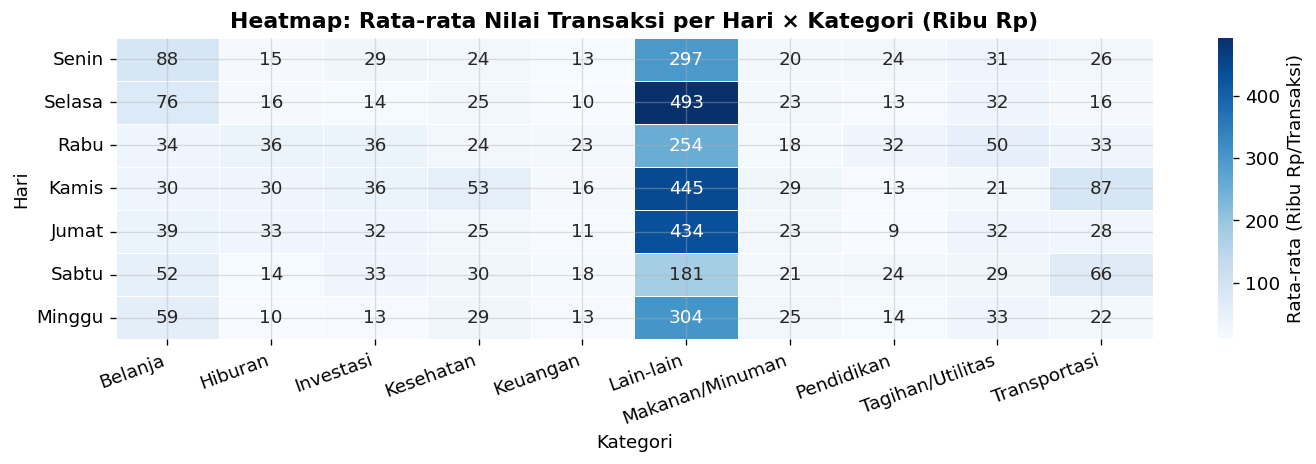

In [33]:
# Heatmap: kategori x hari dalam seminggu
day_kat = df.pivot_table(values='total_pengeluaran', index='hari_minggu', columns='kategori',
                          aggfunc='mean', fill_value=0).reindex(DAY_ORDER)
day_kat.index = DAY_ID

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(day_kat / 1e3, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Rata-rata (Ribu Rp/Transaksi)'}, ax=ax)
ax.set_title('Heatmap: Rata-rata Nilai Transaksi per Hari × Kategori (Ribu Rp)', fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Hari')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### Penjelasan Pertanyaan No 7

Berdasarkan hasil analisis pengeluaran per hari dalam seminggu, hari dengan **total pengeluaran terbesar** adalah **Kamis** dengan total sekitar **Rp77.639.461**. Nilai ini lebih tinggi dibanding hari lainnya dan menunjukkan bahwa aktivitas pengeluaran paling besar pada dataset terjadi pada pertengahan minggu.

Kategori hari dengan total pengeluaran tinggi berikutnya yaitu:

- **Selasa** sekitar **Rp69.442.814**
- **Senin** sekitar **Rp62.790.243**
- **Minggu** sekitar **Rp56.974.782**
- **Jumat** sekitar **Rp53.359.011**

Sementara itu, total pengeluaran relatif lebih rendah pada:

- **Rabu** sekitar **Rp51.138.426**
- **Sabtu** sekitar **Rp50.768.403**

Jika dilihat dari **rata-rata nilai transaksi**, pola yang muncul juga menunjukkan hasil serupa. **Kamis** memiliki rata-rata transaksi tertinggi yaitu sekitar **Rp57.810 per transaksi**, diikuti oleh:

- **Selasa** sekitar **Rp51.978**
- **Senin** sekitar **Rp44.218**
- **Jumat** sekitar **Rp42.997**

Sedangkan rata-rata transaksi terendah terjadi pada:

- **Sabtu** sekitar **Rp40.197**
- **Minggu** sekitar **Rp41.893**
- **Rabu** sekitar **Rp41.917**

Temuan ini menunjukkan bahwa **hari kerja (weekday)** cenderung mendominasi pengeluaran baik dari sisi total maupun rata-rata transaksi. Pengeluaran terbesar tidak terjadi pada akhir pekan, melainkan pada pertengahan minggu terutama hari Kamis, yang dapat mengindikasikan adanya aktivitas pembayaran rutin, kebutuhan operasional, maupun transaksi bernilai lebih besar pada hari kerja.

Heatmap kategori × hari juga memperlihatkan bahwa pola pengeluaran antar kategori tidak sama pada setiap hari. Kategori **Lain-lain** memiliki rata-rata transaksi yang relatif tinggi hampir sepanjang minggu, dengan nilai tertinggi terlihat pada **Selasa (sekitar Rp493 ribu)** dan **Kamis (sekitar Rp445 ribu)** per transaksi. Selain itu, kategori **Makanan/Minuman** dan beberapa kategori lain menunjukkan variasi nilai transaksi yang berbeda tergantung hari terjadinya transaksi.

Secara keseluruhan, hasil analisis menunjukkan bahwa **pola pengeluaran dipengaruhi oleh siklus mingguan**, di mana hari kerja terutama **Kamis dan Selasa** cenderung memiliki aktivitas pengeluaran yang lebih besar dibanding akhir pekan.


---
## 6. Data Dictionary




Tahap ini dilakukan untuk membuat data dictionary sebagai dokumentasi struktur dataset yang digunakan pada proses analisis.

In [36]:
data_dict = pd.DataFrame([
    {
        'Kolom'     : 'tanggal_transaksi',
        'Tipe'      : 'datetime64[ns]',
        'Deskripsi' : 'Tanggal transaksi terjadi',
        'Contoh'    : '2023-04-25',
        'Catatan'   : (
            f'Rentang: '
            f'{df["tanggal_transaksi"].min().date()} '
            f's.d. '
            f'{df["tanggal_transaksi"].max().date()}'
        )
    },
    {
        'Kolom'     : 'nama_produk',
        'Tipe'      : 'object (string)',
        'Deskripsi' : 'Nama/deskripsi item yang dibeli atau transaksi',
        'Contoh'    : 'restaurant dinner',
        'Catatan'   : (
            f'{df["nama_produk"].nunique():,} item unik; '
            f'teks bebas (bahasa campuran EN/ID)'
        )
    },
    {
        'Kolom'     : 'kategori',
        'Tipe'      : 'object (categorical)',
        'Deskripsi' : 'Label kategori pengeluaran (dilabeli manual)',
        'Contoh'    : 'Makanan/Minuman',
        'Catatan'   : (
            f'{len(KATEGORI_LIST)} kategori: '
            + ', '.join(KATEGORI_LIST)
        )
    },
    {
        'Kolom'     : 'total_pengeluaran',
        'Tipe'      : 'int64',
        'Deskripsi' : 'Nilai transaksi dalam satuan rupiah',
        'Contoh'    : '3888',
        'Catatan'   : (
            f'Range: Rp {df["total_pengeluaran"].min():,.0f}'
            f'–Rp {df["total_pengeluaran"].max():,.0f}; '
            f'median=Rp {df["total_pengeluaran"].median():,.0f}; '
            f'right-skewed'
        )
    },
])

print('DATA DICTIONARY')
print('=' * 80)

for _, row in data_dict.iterrows():
    for col in data_dict.columns:
        print(f'{col:10s}: {row[col]}')
    print('-' * 80)

data_dict

DATA DICTIONARY
Kolom     : tanggal_transaksi
Tipe      : datetime64[ns]
Deskripsi : Tanggal transaksi terjadi
Contoh    : 2023-04-25
Catatan   : Rentang: 2015-01-01 s.d. 2024-12-31
--------------------------------------------------------------------------------
Kolom     : nama_produk
Tipe      : object (string)
Deskripsi : Nama/deskripsi item yang dibeli atau transaksi
Contoh    : restaurant dinner
Catatan   : 1,044 item unik; teks bebas (bahasa campuran EN/ID)
--------------------------------------------------------------------------------
Kolom     : kategori
Tipe      : object (categorical)
Deskripsi : Label kategori pengeluaran (dilabeli manual)
Contoh    : Makanan/Minuman
Catatan   : 10 kategori: Lain-lain, Investasi, Belanja, Transportasi, Tagihan/Utilitas, Makanan/Minuman, Kesehatan, Hiburan, Pendidikan, Keuangan
--------------------------------------------------------------------------------
Kolom     : total_pengeluaran
Tipe      : int64
Deskripsi : Nilai transaksi dalam sat

,Kolom,Tipe,Deskripsi,Contoh,Catatan
0,tanggal_transaksi,datetime64[ns],Tanggal transaksi terjadi,2023-04-25,Rentang: 2015-01-01 s.d. 2024-12-31
1,nama_produk,object (string),Nama/deskripsi item yang dibeli atau transaksi,restaurant dinner,"1,044 item unik; teks bebas (bahasa campuran E..."
2,kategori,object (categorical),Label kategori pengeluaran (dilabeli manual),Makanan/Minuman,"10 kategori: Lain-lain, Investasi, Belanja, Tr..."
3,total_pengeluaran,int64,Nilai transaksi dalam satuan rupiah,3888,"Range: Rp 51–Rp 9,500,000; median=Rp 6,840; ri..."


Data dictionary berisi informasi penting mengenai:
- nama kolom,
- tipe data,
- deskripsi atribut,
- contoh isi data,
- serta catatan tambahan terkait karakteristik masing-masing fitur.

Dokumentasi ini membantu memahami isi dataset secara lebih sistematis serta memastikan setiap variabel dapat digunakan dengan tepat pada tahap Exploratory Data Analysis (EDA) maupun analisis lanjutan.

Berdasarkan hasil data dictionary, dataset terdiri atas beberapa atribut utama yaitu:
- atribut waktu (`tanggal_transaksi`) yang menunjukkan kapan transaksi terjadi,
- atribut teks transaksi (`nama_produk`) yang berisi nama atau deskripsi pengeluaran,
- label kategori pengeluaran (`kategori`) hasil proses labeling manual,
- serta atribut numerik (`total_pengeluaran`) yang merepresentasikan nominal transaksi dalam satuan rupiah.

Kolom `nama_produk` memiliki karakteristik berupa teks bebas dengan variasi bahasa Indonesia dan Inggris, sedangkan kolom `kategori` terdiri dari **10 kategori pengeluaran** yang digunakan untuk mengelompokkan transaksi berdasarkan jenis kebutuhannya.

Selain itu, kolom `total_pengeluaran` menunjukkan distribusi yang bersifat **right-skewed**, yaitu sebagian besar transaksi bernilai relatif kecil namun terdapat sejumlah transaksi dengan nominal jauh lebih besar. Kondisi ini menyebabkan rentang nilai transaksi cukup lebar dan menjadi indikasi awal adanya variasi pengeluaran yang tinggi maupun potensi transaksi ekstrem (outlier).

Secara keseluruhan, data dictionary membantu memberikan pemahaman awal mengenai struktur dan karakteristik dataset sehingga proses EDA, visualisasi, serta analisis lanjutan dapat dilakukan secara lebih terarah dan konsisten.


---
## 7. Feature Engineering & Persiapan Model




Tahap feature engineering dilakukan untuk mempersiapkan dataset agar lebih siap digunakan.

In [38]:
from sklearn.preprocessing import LabelEncoder

# Dataset untuk modeling
df_model = df[
    [
        'tanggal_transaksi',
        'nama_produk',
        'kategori',
        'total_pengeluaran'
    ]
].copy()

# 1. Log-transform (atasi right-skewed)
df_model['log_total_pengeluaran'] = np.log1p(
    df_model['total_pengeluaran']
)

# 2. Feature engineering dari tanggal
df_model['tahun'] = (
    df_model['tanggal_transaksi']
    .dt.year
)

df_model['bulan'] = (
    df_model['tanggal_transaksi']
    .dt.month
)

df_model['kuartal'] = (
    df_model['tanggal_transaksi']
    .dt.quarter
)

# 0=Senin, 6=Minggu
df_model['hari_minggu'] = (
    df_model['tanggal_transaksi']
    .dt.dayofweek
)

df_model['is_weekend'] = (
    df_model['hari_minggu']
    .isin([5, 6])
    .astype(int)
)

# 3. Flag pembelian besar (P95)
BIG_PURCHASE_THRESHOLD = (
    df_model['total_pengeluaran']
    .quantile(0.95)
)

df_model['is_big_purchase'] = (
    df_model['total_pengeluaran']
    >= BIG_PURCHASE_THRESHOLD
).astype(int)

print(
    f'Threshold big purchase (P95) : '
    f'Rp {BIG_PURCHASE_THRESHOLD:,.0f}'
)

print(
    f'Jumlah big purchase          : '
    f'{df_model["is_big_purchase"].sum():,} transaksi'
)

print()
print('Fitur yang ditambahkan:')
print(df_model.dtypes)

Threshold big purchase (P95) : Rp 107,601
Jumlah big purchase          : 460 transaksi

Fitur yang ditambahkan:
tanggal_transaksi        datetime64[ns]
nama_produk                      object
kategori                         object
total_pengeluaran               float64
log_total_pengeluaran           float64
tahun                             int32
bulan                             int32
kuartal                           int32
hari_minggu                       int32
is_weekend                        int64
is_big_purchase                   int64
dtype: object


Pada tahap ini dilakukan proses **feature engineering dan persiapan data model** untuk menghasilkan fitur-fitur tambahan yang dapat membantu model machine learning dalam mengenali pola transaksi secara lebih baik.

Beberapa proses yang dilakukan meliputi:

- transformasi log (`log_total_pengeluaran`) untuk mengurangi efek distribusi data yang sangat **right-skewed**,
- ekstraksi fitur waktu dari `tanggal_transaksi` seperti:
  - `tahun`,
  - `bulan`,
  - `kuartal`,
  - dan `hari_minggu`,
- pembuatan fitur `is_weekend` untuk membedakan transaksi yang terjadi pada akhir pekan dan hari kerja,
- serta pembuatan label `is_big_purchase` berdasarkan transaksi yang berada di atas persentil ke-95 (P95).

Hasil feature engineering menunjukkan bahwa:

- threshold transaksi besar (**P95**) berada pada sekitar **Rp107.601**,
- serta terdapat sekitar **460 transaksi** yang termasuk kategori **big purchase**.

Selain itu, proses feature engineering menghasilkan beberapa fitur numerik tambahan yang dapat membantu model dalam mengenali pola transaksi berdasarkan dimensi waktu maupun perilaku pengeluaran pengguna.

Transformasi log pada `total_pengeluaran` juga membantu membuat distribusi data menjadi lebih stabil dengan mengurangi pengaruh transaksi bernilai sangat besar (outlier). Hal ini penting karena data pengeluaran umumnya memiliki distribusi **right-skewed**, sehingga transformasi log dapat meningkatkan kualitas data sebelum digunakan pada tahap pemodelan machine learning.

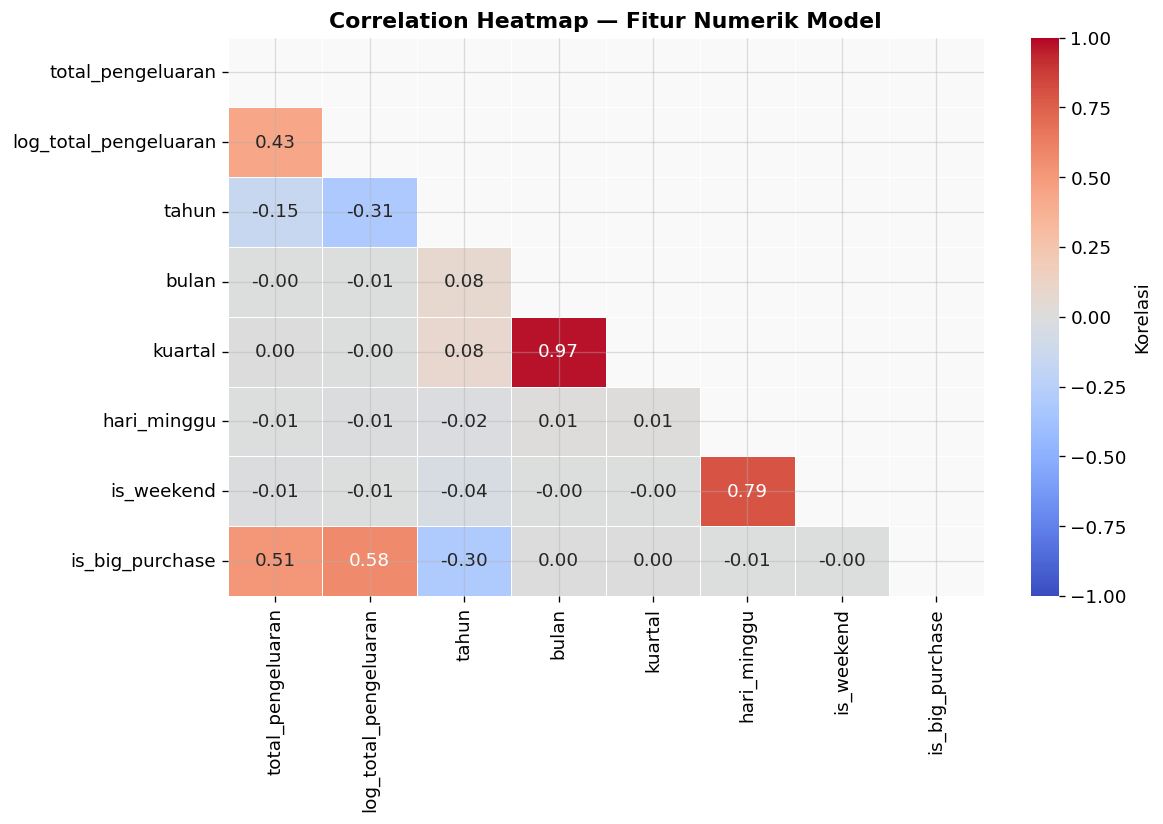

In [40]:
# Correlation heatmap antar fitur numerik
feature_num = ['total_pengeluaran','log_total_pengeluaran','tahun','bulan','kuartal',
               'hari_minggu','is_weekend','is_big_purchase']
corr_matrix = df_model[feature_num].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'label': 'Korelasi'}, ax=ax)
ax.set_title('Correlation Heatmap — Fitur Numerik Model', fontweight='bold')
plt.tight_layout()
plt.show()


Tahap ini dilakukan untuk menganalisis hubungan antar fitur numerik menggunakan **correlation heatmap**.

Fitur yang dianalisis meliputi:
- `total_pengeluaran`
- `log_total_pengeluaran`
- `tahun`
- `bulan`
- `kuartal`
- `hari_minggu`
- `is_weekend`
- `is_big_purchase`

Correlation heatmap digunakan untuk melihat:
- kekuatan hubungan antar fitur,
- arah hubungan (positif atau negatif),
- serta mendeteksi kemungkinan multikolinearitas antar variabel sebelum tahap pemodelan.

Nilai korelasi berada pada rentang:
- mendekati **1** → hubungan positif kuat,
- mendekati **−1** → hubungan negatif kuat,
- mendekati **0** → hubungan lemah atau hampir tidak berkorelasi.

Hasil visualisasi menunjukkan beberapa hubungan penting antar fitur. Variabel `total_pengeluaran` memiliki korelasi positif dengan `log_total_pengeluaran` sebesar sekitar **0,43**, yang menunjukkan bahwa transformasi log masih merepresentasikan nilai transaksi asli namun dalam distribusi yang lebih stabil.

Fitur `is_big_purchase` juga menunjukkan korelasi positif dengan:
- `total_pengeluaran` sekitar **0,51**,
- serta `log_total_pengeluaran` sekitar **0,58**.

Hal ini wajar karena label `is_big_purchase` dibentuk berdasarkan transaksi dengan nominal tinggi (di atas P95), sehingga secara alami berkaitan dengan besarnya nilai transaksi.

Selain itu, fitur waktu `bulan` dan `kuartal` memiliki korelasi positif yang **sangat tinggi** yaitu sekitar **0,97**. Hubungan ini terjadi karena kuartal merupakan turunan langsung dari bulan sehingga keduanya membawa informasi waktu yang hampir serupa.

Sementara itu, fitur seperti `hari_minggu` dan `is_weekend` memiliki korelasi positif cukup tinggi sekitar **0,79**, yang menunjukkan bahwa transaksi akhir pekan sangat berkaitan dengan posisi hari dalam minggu.

Di sisi lain, sebagian besar pasangan fitur lainnya memiliki korelasi yang relatif rendah atau mendekati nol. Hal ini menunjukkan bahwa fitur hasil engineering masih cukup beragam dan tidak sepenuhnya saling menggantikan.

Secara keseluruhan, correlation heatmap menunjukkan bahwa tidak terdapat banyak korelasi ekstrem antar fitur, meskipun hubungan sangat tinggi antara `bulan–kuartal` dan `hari_minggu–is_weekend` perlu diperhatikan karena berasal dari informasi waktu yang saling terkait.

In [41]:
# Label Encoding untuk kolom target
le = LabelEncoder()
df_model['kategori_encoded'] = le.fit_transform(df_model['kategori'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Mapping (kategori → integer):')
for k, v in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f'  {v} → {k}')
print()
print('Distribusi target (encoded):')
print(df_model['kategori_encoded'].value_counts().sort_index())


Label Mapping (kategori → integer):
  0 → Belanja
  1 → Hiburan
  2 → Investasi
  3 → Kesehatan
  4 → Keuangan
  5 → Lain-lain
  6 → Makanan/Minuman
  7 → Pendidikan
  8 → Tagihan/Utilitas
  9 → Transportasi

Distribusi target (encoded):
kategori_encoded
0     862
1     372
2     331
3    1164
4     391
5     446
6    1978
7     703
8    1622
9    1314
Name: count, dtype: int64


Tahap ini dilakukan untuk mengubah label kategori pengeluaran dari bentuk teks menjadi bentuk numerik menggunakan metode **Label Encoding**.

Proses encoding diperlukan karena algoritma machine learning umumnya hanya dapat memproses data numerik, sehingga kategori berbentuk teks perlu direpresentasikan ke dalam kode angka sebelum digunakan pada tahap pemodelan.

Hasil encoding menghasilkan mapping kategori sebagai berikut:

- `0 → Belanja`
- `1 → Hiburan`
- `2 → Investasi`
- `3 → Kesehatan`
- `4 → Keuangan`
- `5 → Lain-lain`
- `6 → Makanan/Minuman`
- `7 → Pendidikan`
- `8 → Tagihan/Utilitas`
- `9 → Transportasi`

Perlu diperhatikan bahwa nilai numerik hasil encoding **tidak menunjukkan urutan maupun tingkat prioritas kategori**, melainkan hanya berfungsi sebagai representasi numerik dari label kategori.

Selain itu, dilakukan pengecekan distribusi target (`kategori_encoded`) untuk melihat jumlah data pada masing-masing kelas kategori. Hasil distribusi menunjukkan:

- Belanja : **862 transaksi**
- Hiburan : **372 transaksi**
- Investasi : **331 transaksi**
- Kesehatan : **1.164 transaksi**
- Keuangan : **391 transaksi**
- Lain-lain : **446 transaksi**
- Makanan/Minuman : **1.978 transaksi**
- Pendidikan : **703 transaksi**
- Tagihan/Utilitas : **1.622 transaksi**
- Transportasi : **1.314 transaksi**

Distribusi tersebut menunjukkan bahwa dataset memiliki variasi jumlah data antar kategori (*class imbalance*) meskipun tidak didominasi secara ekstrem oleh satu kelas tertentu. Kategori **Makanan/Minuman**, **Tagihan/Utilitas**, dan **Transportasi** memiliki jumlah transaksi relatif lebih besar dibanding kategori lainnya, sedangkan kategori seperti **Investasi** dan **Hiburan** memiliki jumlah data yang lebih sedikit.


In [43]:
# Persiapan fitur untuk modeling
# Tahap ini dilakukan sebagai kelanjutan dari feature engineering
# klasifikasi kategori transaksi.

# Definisi fitur (X) dan target (y)
FEATURE_COLS = [
    'log_total_pengeluaran',
    'tahun',
    'bulan',
    'kuartal',
    'hari_minggu',
    'is_weekend',
    'is_big_purchase',
]

TARGET_COL = 'kategori_encoded'

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print('Fitur (X):')
print(X.describe().round(2))
print()

print(f'Target (y): {TARGET_COL}')
print(f'   Shape X : {X.shape}')
print(f'   Shape y : {y.shape}')
print()

# Cek distribusi target
print('Distribusi target:')
print(
    y.value_counts()
     .sort_index()
)

Fitur (X):
       log_total_pengeluaran    tahun    bulan  kuartal  hari_minggu  \
count                9183.00  9183.00  9183.00  9183.00      9183.00   
mean                    9.00  2021.22     6.41     2.47         2.97   
std                     1.53     2.64     3.47     1.12         2.03   
min                     3.95  2015.00     1.00     1.00         0.00   
25%                     8.15  2021.00     3.00     1.00         1.00   
50%                     8.83  2022.00     6.00     2.00         3.00   
75%                     9.83  2023.00     9.00     3.00         5.00   
max                    16.07  2024.00    12.00     4.00         6.00   

       is_weekend  is_big_purchase  
count     9183.00          9183.00  
mean         0.29             0.05  
std          0.45             0.22  
min          0.00             0.00  
25%          0.00             0.00  
50%          0.00             0.00  
75%          1.00             0.00  
max          1.00             1.00  

Target

Tahap ini dilakukan untuk mempersiapkan **fitur (X)** dan **target (y)** yang akan digunakan pada proses deep learning klasifikasi kategori transaksi.

Fitur (`X`) yang digunakan terdiri dari:

- `log_total_pengeluaran`
- `tahun`
- `bulan`
- `kuartal`
- `hari_minggu`
- `is_weekend`
- `is_big_purchase`

Sedangkan target (`y`) yang digunakan adalah:

- `kategori_encoded`

Hasil output menunjukkan bahwa:

- dataset memiliki **9.183 baris data**,
- jumlah fitur yang digunakan sebanyak **7 fitur**,
- shape fitur (`X`) adalah **(9183, 7)**,
- serta shape target (`y`) adalah **(9183, )**.

Statistik deskriptif fitur menunjukkan bahwa nilai `log_total_pengeluaran` memiliki distribusi yang lebih stabil dibandingkan nilai transaksi asli karena telah melalui proses transformasi log untuk mengurangi efek distribusi **right-skewed**.

Fitur waktu seperti `tahun`, `bulan`, `kuartal`, dan `hari_minggu` juga berhasil diekstraksi dengan baik dari atribut tanggal sehingga dapat membantu model dalam mengenali pola temporal transaksi.

Selain itu, fitur `is_weekend` menunjukkan proporsi sekitar **0,29**, yang berarti sebagian transaksi terjadi pada akhir pekan. Sementara itu, fitur `is_big_purchase` memiliki rata-rata sekitar **0,05**, yang menunjukkan bahwa hanya sebagian kecil transaksi termasuk kategori **big purchase** atau transaksi bernilai besar berdasarkan threshold persentil ke-95 (P95).

Distribusi target (`kategori_encoded`) memperlihatkan bahwa jumlah data pada tiap kategori tidak sepenuhnya seimbang. Beberapa kategori seperti **Makanan/Minuman**, **Tagihan/Utilitas**, dan **Transportasi** memiliki jumlah data lebih besar dibanding kategori lainnya seperti **Investasi** dan **Hiburan**. Kondisi ini menunjukkan adanya variasi distribusi kelas (*class imbalance*) yang perlu diperhatikan pada tahap pemodelan.

Secara keseluruhan, tahap ini menunjukkan bahwa dataset telah berhasil dipersiapkan dalam format numerik dan memiliki struktur yang siap digunakan untuk proses evaluasi model klasifikasi kategori transaksi.

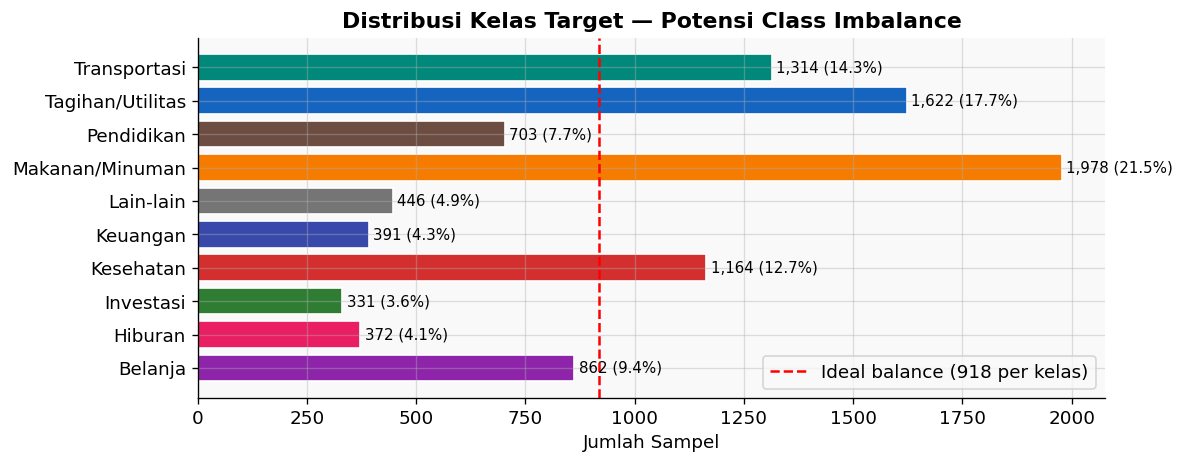

Imbalance ratio (max/min) : 6.0x
→ Pertimbangkan SMOTE atau class_weight="balanced" saat modeling


In [44]:
# Class imbalance
fig, ax = plt.subplots(figsize=(10, 4))
class_dist = y.value_counts().sort_index()
class_labels = [le.inverse_transform([i])[0] for i in class_dist.index]
colors_cls = [KATEGORI_COLOR.get(k, '#757575') for k in class_labels]

bars = ax.barh(class_labels, class_dist.values, color=colors_cls, edgecolor='white')
for bar, val in zip(bars, class_dist.values):
    pct = val / len(y) * 100
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Jumlah Sampel')
ax.set_title('Distribusi Kelas Target — Potensi Class Imbalance', fontweight='bold')
ax.axvline(len(y) / y.nunique(), color='red', linestyle='--', linewidth=1.5,
           label=f'Ideal balance ({len(y)//y.nunique():,} per kelas)')
ax.legend()
plt.tight_layout()
plt.show()

imbalance_ratio = class_dist.max() / class_dist.min()
print(f'Imbalance ratio (max/min) : {imbalance_ratio:.1f}x')
print('→ Pertimbangkan SMOTE atau class_weight="balanced" saat modeling')


Tahap ini dilakukan untuk menganalisis distribusi kelas target (`kategori_encoded`) serta mendeteksi potensi **class imbalance** pada dataset sebelum proses machine learning dilakukan.

Visualisasi menunjukkan bahwa jumlah data pada masing-masing kategori belum tersebar secara sepenuhnya merata. Kategori **Makanan/Minuman** memiliki jumlah sampel terbesar yaitu sekitar **1.978 data (21,5%)**, sedangkan kategori **Investasi** memiliki jumlah sampel paling sedikit yaitu sekitar **331 data (3,6%)**.

Distribusi kategori lainnya meliputi:

- Tagihan/Utilitas : **1.622 data (17,7%)**
- Transportasi : **1.314 data (14,3%)**
- Kesehatan : **1.164 data (12,7%)**
- Belanja : **862 data (9,4%)**
- Pendidikan : **703 data (7,7%)**
- Lain-lain : **446 data (4,9%)**
- Keuangan : **391 data (4,3%)**
- Hiburan : **372 data (4,1%)**

Garis merah pada visualisasi menunjukkan kondisi ideal apabila seluruh kelas memiliki jumlah data yang seimbang, yaitu sekitar **918 data per kategori**.

Hasil perhitungan menunjukkan nilai **imbalance ratio (max/min)** sekitar **6,0x**, yang berarti jumlah data pada kategori terbesar sekitar enam kali lebih banyak dibanding kategori terkecil.

Kondisi ini menunjukkan adanya **class imbalance** dalam dataset. Meskipun belum tergolong ekstrem, ketidakseimbangan distribusi kelas tetap perlu diperhatikan karena dapat menyebabkan model machine learning cenderung lebih baik dalam mengenali kategori mayoritas dibanding kategori minoritas.

Oleh karena itu, pada tahap pemodelan dapat dipertimbangkan penggunaan teknik seperti:

- `class_weight='balanced'`,
- oversampling,
- undersampling,
- maupun **SMOTE (Synthetic Minority Oversampling Technique)**

untuk membantu meningkatkan performa model pada kategori dengan jumlah data yang lebih sedikit.

Secara keseluruhan, hasil analisis menunjukkan bahwa dataset masih layak digunakan untuk pemodelan, namun aspek ketidakseimbangan kelas perlu dipertimbangkan pada tahap training dan evaluasi model.


---
## 8. Export Dataset




Tahap ini dilakukan untuk menyimpan dataset hasil cleaning dan feature preparation ke dalam file CSV agar dapat digunakan pada proses analisis lanjutan ke dashboard.

In [46]:
# Export dataset bersih (kolom inti saja)
df_export = df[['tanggal_transaksi', 'nama_produk', 'kategori', 'total_pengeluaran']].copy()
output_clean = 'pengeluaran_clean.csv'
df_export.to_csv(output_clean, index=False)

print(f' Dataset bersih tersimpan: {output_clean}')
print(f'   Shape  : {df_export.shape}')
print(f'   Kolom  : {df_export.columns.tolist()}')
print()
df_export.head()

 Dataset bersih tersimpan: pengeluaran_clean.csv
   Shape  : (9183, 4)
   Kolom  : ['tanggal_transaksi', 'nama_produk', 'kategori', 'total_pengeluaran']



,tanggal_transaksi,nama_produk,kategori,total_pengeluaran
0,2015-01-01,share auto - hospital to brc station,Transportasi,1900.0
1,2015-01-01,tea,Makanan/Minuman,1900.0
2,2015-01-01,share jeep - place t top to base,Transportasi,3800.0
3,2015-01-01,share jeep - place t to brc,Transportasi,11400.0
4,2015-01-01,monument,Lain-lain,7600.0


Dataset akhir yang disimpan hanya berisi kolom inti yang relevan, yaitu:

- `tanggal_transaksi`
- `nama_produk`
- `kategori`
- `total_pengeluaran`

Pemilihan kolom inti dilakukan untuk menghasilkan dataset yang lebih ringkas dan fokus pada atribut utama yang merepresentasikan informasi transaksi, sehingga lebih mudah digunakan pada analisis lanjutan maupun proses pemodelan machine learning.

Hasil export menunjukkan bahwa dataset akhir memiliki:

- **9.183 baris data**
- **4 kolom utama**

Dataset bersih berhasil disimpan dengan nama:

`pengeluaran_clean.csv`

Dataset ini merepresentasikan hasil akhir dari proses data wrangling dan pembersihan data, di mana data telah melalui tahap validasi, penanganan missing value, standarisasi kategori, serta pengecekan kualitas data sehingga siap digunakan kembali sebagai dataset bersih (*clean dataset*).

In [48]:
# Export dataset model-ready

df_model_export = df_model[
    [
        'tanggal_transaksi',
        'nama_produk',
        'total_pengeluaran',
        'log_total_pengeluaran',
        'tahun',
        'bulan',
        'kuartal',
        'hari_minggu',
        'is_weekend',
        'is_big_purchase',
        'kategori',
        'kategori_encoded'
    ]
].copy()

output_model = 'pengeluaran_model_ready.csv'

df_model_export.to_csv(
    output_model,
    index=False
)

print(
    f'Dataset model-ready tersimpan: '
    f'{output_model}'
)

print(
    f'   Shape : '
    f'{df_model_export.shape}'
)

print(
    f'   Kolom : '
    f'{df_model_export.columns.tolist()}'
)

print()

df_model_export.head()

Dataset model-ready tersimpan: pengeluaran_model_ready.csv
   Shape : (9183, 12)
   Kolom : ['tanggal_transaksi', 'nama_produk', 'total_pengeluaran', 'log_total_pengeluaran', 'tahun', 'bulan', 'kuartal', 'hari_minggu', 'is_weekend', 'is_big_purchase', 'kategori', 'kategori_encoded']



,tanggal_transaksi,nama_produk,total_pengeluaran,log_total_pengeluaran,tahun,bulan,kuartal,hari_minggu,is_weekend,is_big_purchase,kategori,kategori_encoded
0,2015-01-01,share auto - hospital to brc station,1900.0,7.550135,2015,1,1,3,0,0,Transportasi,9
1,2015-01-01,tea,1900.0,7.550135,2015,1,1,3,0,0,Makanan/Minuman,6
2,2015-01-01,share jeep - place t top to base,3800.0,8.243019,2015,1,1,3,0,0,Transportasi,9
3,2015-01-01,share jeep - place t to brc,11400.0,9.341456,2015,1,1,3,0,0,Transportasi,9
4,2015-01-01,monument,7600.0,8.936035,2015,1,1,3,0,0,Lain-lain,5


### Ringkasan Dataset yang Dihasilkan

| File | Isi | Tujuan |
|---|---|---|
| `pengeluaran_clean.csv` | Dataset bersih hasil data wrangling dan validasi | Analisis data dan EDA lanjutan |
| `pengeluaran_model_ready.csv` | Dataset hasil feature engineering dan encoding | Persiapan serta training model deep learning |

Dataset `pengeluaran_clean.csv` berisi kolom inti transaksi yang telah melalui proses pembersihan data, sedangkan `pengeluaran_model_ready.csv` memuat fitur tambahan hasil feature engineering serta label encoding sehingga siap digunakan pada tahap pemodelan.

 **Reminder saat modeling:**
- Pisahkan fitur (`X`) dan target (`y`) sebelum proses training model:
  - `X = df_model[FEATURE_COLS]`
  - `y = df_model['kategori_encoded']`
- Lakukan **train-test split** sebelum proses fitting model agar evaluasi performa lebih objektif.
- Perhatikan potensi **class imbalance** pada target dan pertimbangkan penggunaan `class_weight='balanced'` atau teknik resampling bila diperlukan.


---
## 9. Kesimpulan




In [50]:
print('=' * 65)
print('RINGKASAN EDA')
print('=' * 65)

print(f'Total transaksi      : {len(df):,}')
print(
    f'Periode              : '
    f'{df["tanggal_transaksi"].min().date()} '
    f's.d. '
    f'{df["tanggal_transaksi"].max().date()}'
)

print(
    f'Total pengeluaran    : '
    f'Rp {df["total_pengeluaran"].sum():,.0f}'
)

print(
    f'Rata-rata per bulan  : '
    f'Rp {df.groupby("bulan_nama")["total_pengeluaran"].sum().mean():,.0f}'
)

print(
    f'Produk unik          : '
    f'{df["nama_produk"].nunique():,}'
)

print(
    f'Missing value dihapus: '
    f'{before - len(df):,} baris'
)

print(
    f'Duplikat             : '
    f'{df.duplicated().sum():,}'
)

print()

print('JAWABAN BUSINESS QUESTIONS')
print('-' * 65)

# BQ1
kat_sum = (
    df.groupby('kategori')['total_pengeluaran']
      .sum()
)

top_kat = kat_sum.idxmax()
top_kat_val = kat_sum.max()

print(
    f'1 | Kategori terbesar (total) : '
    f'{top_kat} '
    f'(Rp {top_kat_val:,.0f})'
)

# BQ2
yearly2 = (
    df.groupby('tahun')['total_pengeluaran']
      .sum()
)

growth_pct = (
    yearly2.pct_change()
           .dropna()
           .mul(100)
           .round(1)
           .tolist()
)

print(
    '2 | Tren tahunan             : '
    'Fluktuatif dengan beberapa lonjakan'
)
print(
    f'     Growth rates (%)       : '
    f'{growth_pct}'
)

# BQ3
top_bulan_name = monthly_avg.idxmax()

print(
    f'3 | Bulan rata-rata tertinggi: '
    f'{top_bulan_name}'
)

# BQ4
top_freq = (
    df["kategori"]
    .value_counts()
    .idxmax()
)

top_freq_count = (
    df["kategori"]
    .value_counts()
    .max()
)

top_avg_kat = (
    df.groupby("kategori")["total_pengeluaran"]
      .mean()
      .idxmax()
)

top_avg_val = (
    df.groupby("kategori")["total_pengeluaran"]
      .mean()
      .max()
)

print(
    f'4 | Frekuensi tertinggi     : '
    f'{top_freq} '
    f'({top_freq_count:,} transaksi)'
)

print(
    f'     Mean transaksi terbesar: '
    f'{top_avg_kat} '
    f'(Rp {top_avg_val:,.0f})'
)

# BQ5
outlier_z_count = (
    np.abs(
        stats.zscore(
            df["total_pengeluaran"]
        )
    ) > 3
).sum()

print(
    f'5 | Outlier (Z>3)           : '
    f'{outlier_z_count:,} transaksi'
)

# BQ6
print(
    '6 | Komposisi tahunan       : '
    'Berubah antar tahun; '
    'Lain-lain masih dominan namun proporsi kategori lain ikut berubah'
)

# BQ7
print(
    f'7 | Hari pengeluaran tertinggi : '
    f'{day_stats["total"].idxmax()} (total) / '
    f'{day_stats["rata_rata"].idxmax()} (rata-rata transaksi)'
)

RINGKASAN EDA
Total transaksi      : 9,183
Periode              : 2015-01-01 s.d. 2024-12-31
Total pengeluaran    : Rp 422,113,142
Rata-rata per bulan  : Rp 4,538,851
Produk unik          : 1,044
Missing value dihapus: 0 baris
Duplikat             : 0

JAWABAN BUSINESS QUESTIONS
-----------------------------------------------------------------
1 | Kategori terbesar (total) : Lain-lain (Rp 154,244,928)
2 | Tren tahunan             : Fluktuatif dengan beberapa lonjakan
     Growth rates (%)       : [91.1, 49.5, -19.3, -52.5, 11.0, -18.1, 25.9]
3 | Bulan rata-rata tertinggi: Jan
4 | Frekuensi tertinggi     : Makanan/Minuman (1,978 transaksi)
     Mean transaksi terbesar: Lain-lain (Rp 345,841)
5 | Outlier (Z>3)           : 108 transaksi
6 | Komposisi tahunan       : Berubah antar tahun; Lain-lain masih dominan namun proporsi kategori lain ikut berubah
7 | Hari pengeluaran tertinggi : Kamis (total) / Kamis (rata-rata transaksi)


## Kesimpulan

Berdasarkan hasil **Exploratory Data Analysis (EDA)**, dataset pengeluaran menunjukkan pola transaksi yang cukup dinamis dengan distribusi nilai transaksi yang bersifat **right-skewed**, yaitu sebagian besar transaksi bernilai relatif kecil namun terdapat sejumlah transaksi bernilai sangat besar yang memengaruhi distribusi data.

Hasil analisis menunjukkan bahwa kategori **Lain-lain** memiliki total pengeluaran terbesar dengan nilai sekitar **Rp154,2 juta**, sedangkan kategori dengan frekuensi transaksi tertinggi adalah **Makanan/Minuman** dengan sekitar **1.978 transaksi**. Temuan ini menunjukkan bahwa kategori dengan jumlah transaksi terbanyak tidak selalu menjadi kategori dengan total pengeluaran terbesar.

Analisis tren tahunan memperlihatkan bahwa pola pengeluaran bersifat **fluktuatif** dengan beberapa periode mengalami lonjakan maupun penurunan. Hal ini menunjukkan bahwa perilaku pengeluaran tidak bergerak secara linear dari tahun ke tahun, melainkan dipengaruhi oleh kebutuhan dan aktivitas transaksi pada periode tertentu.

Pada analisis temporal, bulan **Januari** memiliki rata-rata pengeluaran tertinggi berdasarkan perhitungan lintas tahun, sedangkan dari sisi mingguan, **Kamis** menjadi hari dengan total maupun rata-rata transaksi terbesar. Temuan ini menunjukkan bahwa waktu memiliki pengaruh terhadap pola pengeluaran pengguna.

Selain itu, analisis outlier menunjukkan adanya **108 transaksi anomali (Z-score > 3)** yang berkontribusi terhadap distribusi data yang tidak normal. Kehadiran transaksi bernilai tinggi ini perlu diperhatikan karena dapat memengaruhi hasil analisis statistik maupun performa model.

Tahap **feature engineering** juga berhasil menghasilkan beberapa fitur tambahan yang relevan, seperti:
- transformasi log (`log_total_pengeluaran`),
- fitur waktu (`tahun`, `bulan`, `kuartal`, `hari_minggu`),
- indikator akhir pekan (`is_weekend`),
- serta label transaksi besar (`is_big_purchase`).

Proses ini membantu menghasilkan data yang lebih stabil dan informatif untuk analisis lanjutan maupun pengembangan model **Deep Learning**.

Pada akhirnya, dataset berhasil dipersiapkan dalam dua bentuk utama, yaitu:
- **dataset clean** (`pengeluaran_clean.csv`) untuk kebutuhan analisis dan visualisasi,
- serta **dataset model-ready** (`pengeluaran_model_ready.csv`) yang telah melalui feature engineering dan encoding sehingga siap digunakan pada proses **Deep Learning** untuk klasifikasi kategori transaksi.